# COSC2753 Assignment 2 — Fashion Intelligence System
# Data Preprocessing (Tasks 1-3)

One notebook that prepares the data for:
- **Task 1** — predict `articleType`
- **Task 2** — predict `season`
- **Task 3** — predict `gender` and `usage`

**What's in this notebook:**
1. Import libraries
2. Load the dataset
3. Look at the CSV and the images
4. Split into train and validation
5. Explore the train data
6. Process the data, and explain each decision per task

## 1. Import Libraries

In [419]:
import os
import json
import pickle
import hashlib
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.stats import chi2_contingency

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score

import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import torchvision.transforms as T

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [ ]:
DATA_DIR = Path("data/raw/FashionDataset")
OUT_DIR = Path("processed")
OUT_DIR.mkdir(exist_ok=True)

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR = DATA_DIR / "test" / "images_test"

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")

[OK] FashionDataset/train/styles_train.csv
[OK] FashionDataset/train/images_train
[OK] FashionDataset/test/styles_prediction.csv
[OK] FashionDataset/test/images_test


## 3. Looking at `styles_train.csv` and the Images

### 3.1 First look at the CSV

In [421]:
df = pd.read_csv(TRAIN_CSV)
print(df.columns.tolist())
print(df.shape)
df.head(3)

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'Unnamed: 10', 'Unnamed: 11']
(38617, 12)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,Unnamed: 10,Unnamed: 11
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,NaN,NaN
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,NaN,NaN
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,NaN,NaN


In [422]:
# The raw CSV has stray commas in some rows, which pandas turns into extra
# 'Unnamed: N' columns. Drop them.
unnamed_cols = df.columns[df.columns.str.startswith('Unnamed')].tolist()
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
print(f"Dropped {len(unnamed_cols)} malformed column(s): {unnamed_cols}")
print(df.columns.tolist())
print(df.shape)

Dropped 2 malformed column(s): ['Unnamed: 10', 'Unnamed: 11']
['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
(38617, 10)


### 3.2 Image ↔ CSV alignment (full dataset, before any split)

Checked here rather than after splitting, since a row with no matching image file can't be assigned to either split.

In [423]:
csv_ids = set(df['id'].astype(str))
disk_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob("*.jpg")}

missing_images = sorted(csv_ids - disk_ids)   # CSV rows with no image file
extra_images = sorted(disk_ids - csv_ids)     # image files with no CSV row

print(f"CSV rows with no image file: {len(missing_images)} -> {missing_images}")
print(f"Image files with no CSV row: {len(extra_images)}")

CSV rows with no image file: 5 -> ['12347', '39401', '39403', '39410', '39425']
Image files with no CSV row: 0


In [424]:
# Drop the unmatched rows now, before the split, so 'df' and its image folder
# stay aligned for every downstream step (EDA, split, processing).
df = df[~df['id'].astype(str).isin(missing_images)].reset_index(drop=True)
df['id'] = df['id'].astype(str).str.strip()
print(f"Remaining rows: {df.shape[0]}")

Remaining rows: 38612


### 3.3 Image integrity: corrupt files and exact duplicates

In [425]:
# Corrupt / unopenable images
corrupt = []
for img_id in df['id']:
    try:
        with Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg") as im:
            im.verify()
    except Exception as e:
        corrupt.append((img_id, str(e)))

print(f"Corrupt/unopenable images: {len(corrupt)}")
for img_id, err in corrupt[:10]:
    print(f"  {img_id}: {err}")

Corrupt/unopenable images: 0


In [426]:
# Exact duplicate images (byte-for-byte, via md5 hash). The resulting 'dup_group'
# is needed later: it's what the train/val split is grouped on, so two copies of
# the same product photo can never end up on opposite sides of the split.
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_group = {}
group_ids = []
for img_id in df['id']:
    h = file_hash(IMAGES_TRAIN_DIR / f"{img_id}.jpg")
    if h not in hash_to_group:
        hash_to_group[h] = img_id       # first id seen becomes the group label
    group_ids.append(hash_to_group[h])

df['dup_group'] = group_ids
n_groups = df['dup_group'].nunique()
n_dupe_rows = len(df) - n_groups
print(f"{n_groups} unique image groups out of {len(df)} rows "
      f"({n_dupe_rows} rows are exact duplicates of another row)")

37849 unique image groups out of 38612 rows (763 rows are exact duplicates of another row)


### 3.4 Quick visual sanity check

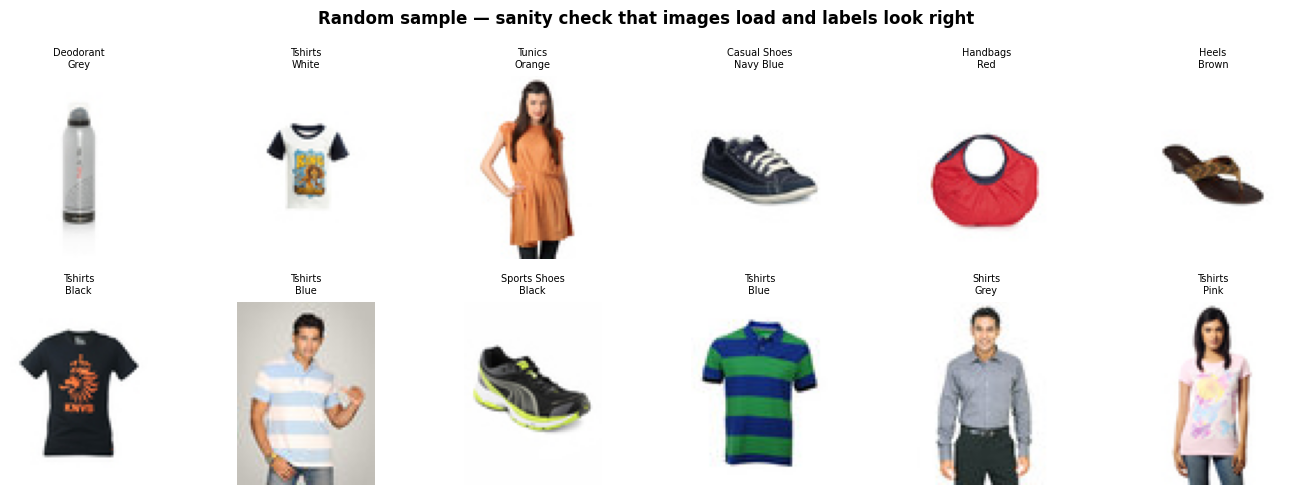

In [427]:
sample = df.sample(12, random_state=RANDOM_STATE)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (_, r) in zip(axes.flat, sample.iterrows()):
    ax.imshow(Image.open(IMAGES_TRAIN_DIR / f"{r['id']}.jpg"))
    ax.axis("off")
    ax.set_title(f"{r['articleType']}\n{r['baseColour']}", fontsize=7)
fig.suptitle("Random sample — sanity check that images load and labels look right", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

**Why not a plain random split:** a plain split doesn't check for duplicate images. We found 763 exact-duplicate image pairs earlier — a plain random split could put one copy in train and the other in validation. That's leakage: the model would basically get tested on a picture it already trained on.

**Why we split on `masterCategory`, not `articleType`:** `articleType` has a lot of rare classes. To split evenly on it, we'd first need to decide which classes count as "rare" — and if we work that out using the full dataset (train and validation together), we'd be using validation labels to help set up training. `masterCategory` avoids this problem. It only has a few categories (Apparel, Accessories, Footwear, and so on) and all of them have plenty of samples, so we can split on it directly with no extra decisions needed. The `articleType` rare-class decision is made later, after the split, using only the train data (see Section 6.3).

**Trade-off:** splitting on `masterCategory` keeps the broad categories balanced between train and validation, but it doesn't guarantee every single `articleType` class is split perfectly evenly. With about 29,000 training rows, this is a small price to pay for avoiding leakage completely.

**What we do:** one `StratifiedGroupKFold` split (about 75/25) — stratified on `masterCategory`, grouped on `dup_group` so duplicate images always stay on the same side. We only use one split, not full cross-validation: with ~29,000 rows this is enough data for a stable result, and doing 4-fold cross-validation would mean training every model four times over — time better spent improving the models themselves.

### 4.1 Doing the split

One more thing before splitting: `masterCategory` needs at least a handful of rows in every one of its categories for the split to work properly. A category with only one or two rows total can't be divided across train and validation at all. Since `masterCategory` isn't a prediction target for any task, dropping a tiny number of rows here doesn't touch anything the model is being trained to predict — it's a mechanical fix, not a modeling decision.

In [428]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)  # 1 fold ~= 25%

# masterCategory needs at least n_splits rows per category for a clean split. A category
# with fewer rows than that can't be divided properly and ends up placed by chance --
# drop those rows first rather than let that happen silently.
master_counts = df['masterCategory'].value_counts()
too_rare_master = master_counts[master_counts < sgkf.get_n_splits()].index
if len(too_rare_master):
    n_dropped = df['masterCategory'].isin(too_rare_master).sum()
    print(f"Dropping {n_dropped} row(s) with a masterCategory that has fewer than "
          f"{sgkf.get_n_splits()} samples total: {list(too_rare_master)}")
    df = df[~df['masterCategory'].isin(too_rare_master)].reset_index(drop=True)

train_idx, val_idx = next(sgkf.split(df, df['masterCategory'], groups=df['dup_group']))
train_data = df.iloc[train_idx].reset_index(drop=True)
val_data = df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {train_data.shape[0]}, Val: {val_data.shape[0]}")

# --- sanity checks ---
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate-image groups appearing in BOTH splits: {len(overlap)} (should be 0)")

missing_master = set(df['masterCategory'].unique()) - set(train_data['masterCategory'].unique())
print(f"masterCategory classes missing from train: {missing_master if missing_master else 'none'}")

Dropping 1 row(s) with a masterCategory that has fewer than 4 samples total: ['Home']
Train: 28958, Val: 9653
Duplicate-image groups appearing in BOTH splits: 0 (should be 0)
masterCategory classes missing from train: none


## 5. Exploring the Train Data

This only looks at `train_data`, after the split — as the course asks, and so nothing below is influenced by the validation data.

### 5.1 Structure & overview

In [429]:
print(train_data.columns.tolist())
print(train_data.shape)
train_data.head()

['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'dup_group']
(28958, 11)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,dup_group
0,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,1164
1,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,1165
2,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,1525
3,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,1526
4,1528,Men,Apparel,Topwear,Jackets,Black,Fall,2010,Sports,Puma Men Ferrari Black Fleece Jacket,1528


In [430]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28958 entries, 0 to 28957
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  28958 non-null  str  
 1   gender              28958 non-null  str  
 2   masterCategory      28958 non-null  str  
 3   subCategory         28958 non-null  str  
 4   articleType         28958 non-null  str  
 5   baseColour          28948 non-null  str  
 6   season              28945 non-null  str  
 7   year                28958 non-null  int64
 8   usage               28902 non-null  str  
 9   productDisplayName  28954 non-null  str  
 10  dup_group           28958 non-null  str  
dtypes: int64(1), str(10)
memory usage: 2.4 MB


### 5.2 Missing values

In [431]:
missing = train_data.isnull().sum()
missing_pct = (missing / len(train_data)) * 100
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct.round(2)}).sort_values('missing', ascending=False)
missing_df

,missing,pct
usage,56,0.19
season,13,0.04
baseColour,10,0.03
productDisplayName,4,0.01
id,0,0.00
gender,0,0.00
masterCategory,0,0.00
subCategory,0,0.00
articleType,0,0.00
year,0,0.00


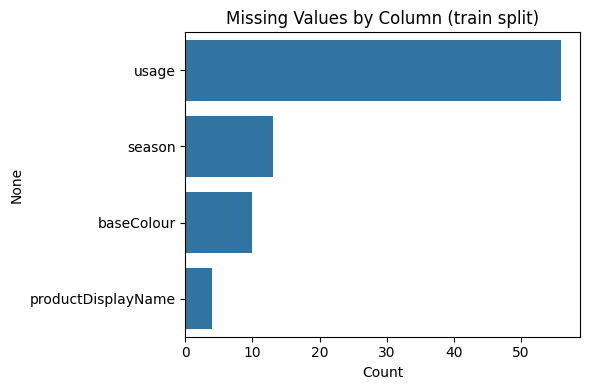

In [432]:
nonzero_missing = missing[missing > 0].sort_values(ascending=False)
if len(nonzero_missing):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=nonzero_missing.values, y=nonzero_missing.index)
    plt.title('Missing Values by Column (train split)')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

### 5.3 Duplicate rows (metadata-level)

In [433]:
print(f"Duplicate rows: {train_data.duplicated().sum()}")
print(f"Duplicate ids: {train_data['id'].duplicated().sum()}")

Duplicate rows: 0
Duplicate ids: 0


### 5.4 Category distributions

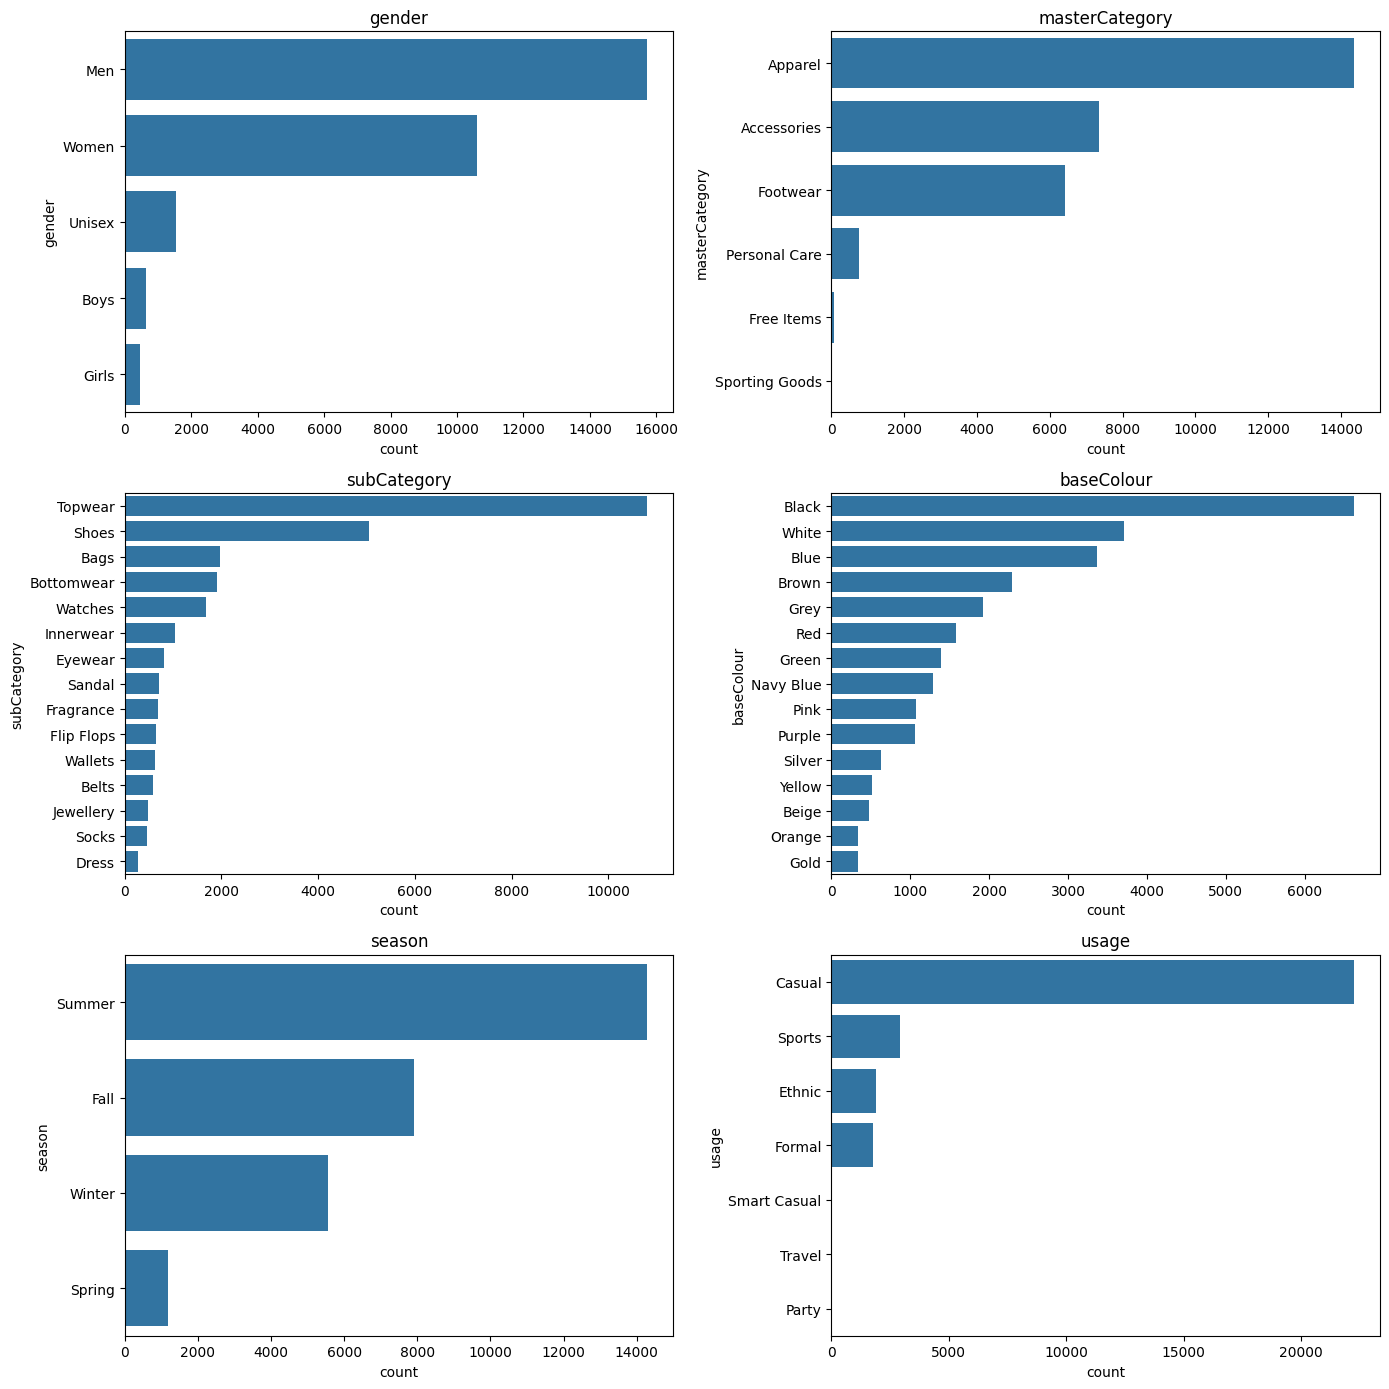

In [434]:
cat_cols = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season', 'usage']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    order = train_data[col].value_counts().index[:15]  # top 15 to keep it readable
    sns.countplot(data=train_data, y=col, order=order, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [435]:
print("Category distributions (summary):\n")
for col in cat_cols + ['articleType']:
    vc = train_data[col].value_counts()
    top_val, top_count = vc.index[0], vc.iloc[0]
    top_pct = top_count / len(train_data) * 100
    n_classes = vc.shape[0]
    least_val, least_count = vc.index[-1], vc.iloc[-1]
    print(f"- {col}: {n_classes} categories. "
          f"Most common is '{top_val}' ({top_count} items, {top_pct:.1f}%). "
          f"Least common is '{least_val}' ({least_count} items).")

Category distributions (summary):

- gender: 5 categories. Most common is 'Men' (15719 items, 54.3%). Least common is 'Girls' (469 items).
- masterCategory: 6 categories. Most common is 'Apparel' (14357 items, 49.6%). Least common is 'Sporting Goods' (18 items).
- subCategory: 39 categories. Most common is 'Topwear' (10800 items, 37.3%). Least common is 'Bath and Body' (1 items).
- baseColour: 46 categories. Most common is 'Black' (6622 items, 22.9%). Least common is 'Rose' (2 items).
- season: 4 categories. Most common is 'Summer' (14282 items, 49.3%). Least common is 'Spring' (1184 items).
- usage: 7 categories. Most common is 'Casual' (22247 items, 76.8%). Least common is 'Party' (11 items).
- articleType: 121 categories. Most common is 'Tshirts' (5122 items, 17.7%). Least common is 'Lounge Tshirts' (1 items).


### 5.5 The long tail in `articleType` (too many classes for a normal count plot)

In [436]:
vc = train_data['articleType'].value_counts()
print(f"Distinct articleType classes in train: {train_data['articleType'].nunique()}")
print(f"Classes with fewer than 10 samples: {(vc < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc < 5).sum()}")
vc.head(15)

Distinct articleType classes in train: 121
Classes with fewer than 10 samples: 39
Classes with fewer than 5 samples:  21


articleType
Tshirts         5122
Shirts          2306
Casual Shoes    2014
Watches         1679
Sports Shoes    1464
Tops            1197
Kurtas          1171
Handbags        1076
Sunglasses       813
Heels            775
Sandals          664
Flip Flops       651
Wallets          627
Belts            598
Backpacks        524
Name: count, dtype: int64

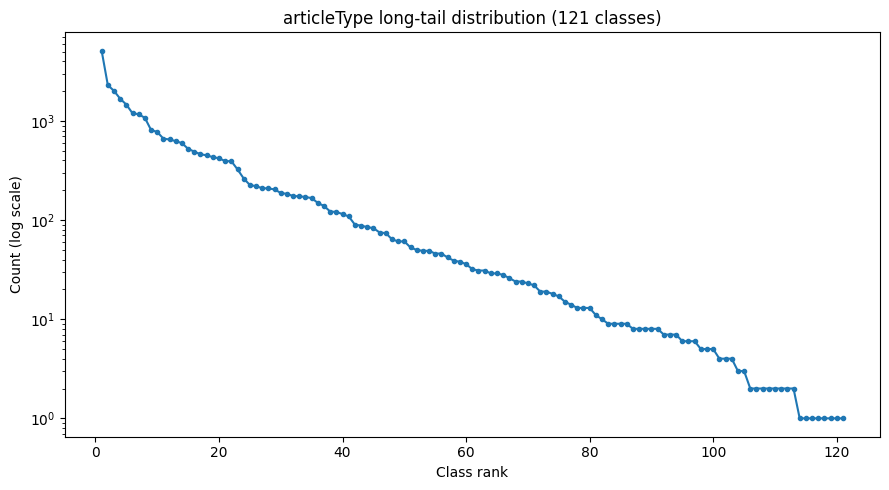

In [437]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(vc) + 1), vc.values, marker='o', markersize=3)
ax.set_yscale('log')
ax.set_xlabel('Class rank')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'articleType long-tail distribution ({len(vc)} classes)')
plt.tight_layout()
plt.show()

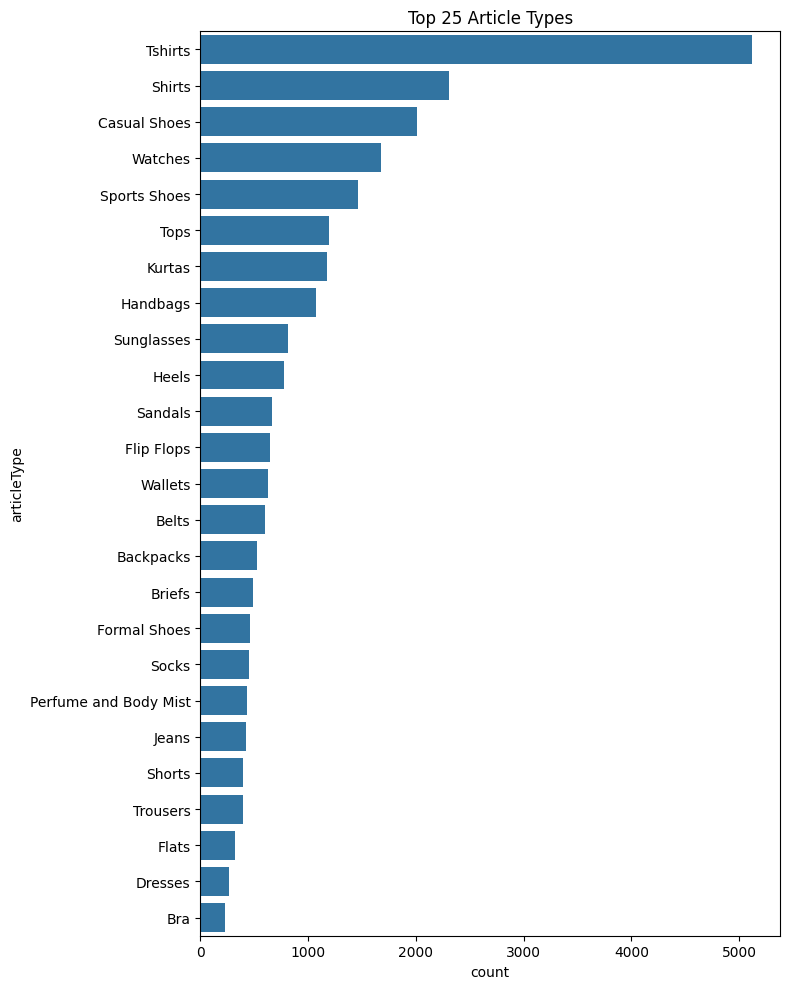

In [438]:
N = 25
plt.figure(figsize=(8, 10))
top_article = train_data['articleType'].value_counts().index[:N]
sns.countplot(data=train_data, y='articleType', order=top_article)
plt.title(f'Top {N} Article Types')
plt.tight_layout()
plt.show()

### 5.6 Year distribution & outliers

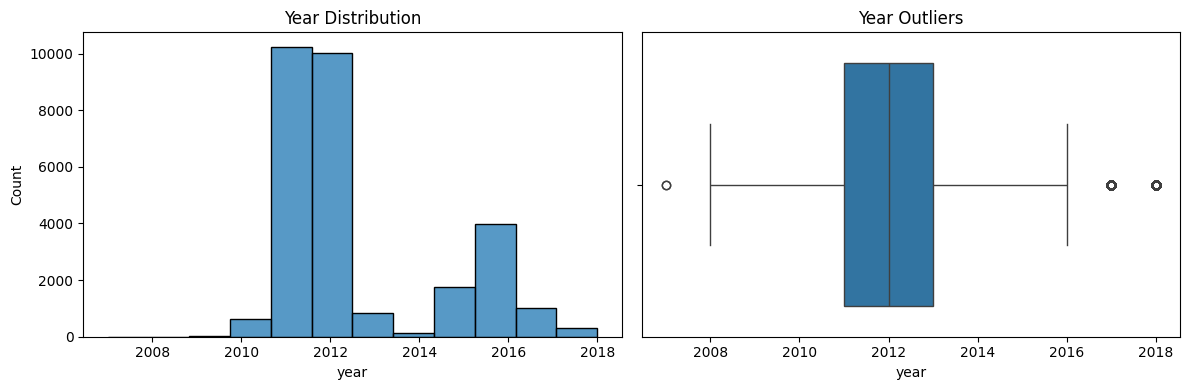

In [439]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_data['year'], bins=train_data['year'].nunique(), ax=axes[0])
axes[0].set_title('Year Distribution')
sns.boxplot(x=train_data['year'], ax=axes[1])
axes[1].set_title('Year Outliers')
plt.tight_layout()
plt.show()

In [440]:
year_counts = train_data['year'].value_counts().sort_index()

q1 = train_data['year'].quantile(0.25)
q3 = train_data['year'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_years = train_data[(train_data['year'] < lower_bound) | (train_data['year'] > upper_bound)]['year']
outlier_summary = outlier_years.value_counts().sort_index()

print(f"Data spans {train_data['year'].min():.0f} to {train_data['year'].max():.0f}.")
print(f"Most items are from {year_counts.idxmax():.0f} ({year_counts.max()} items).")
print(f"Outlier years (IQR rule): {outlier_summary.to_dict()}")

Data spans 2007 to 2018.
Most items are from 2011 (10241 items).
Outlier years (IQR rule): {2007: 2, 2017: 1003, 2018: 303}


### 5.7 Cramér's V — how strongly the feature columns are related

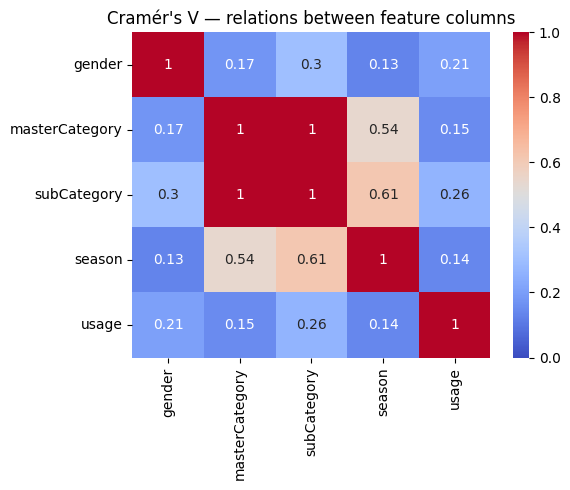

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

feature_cols = ['gender', 'masterCategory', 'subCategory', 'season', 'usage', 'baseColour', 'year', 'productDisplayName']
corr_matrix = pd.DataFrame(index=feature_cols, columns=feature_cols, dtype=float)
for c1, c2 in combinations(feature_cols, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    corr_matrix.loc[c1, c2] = v
    corr_matrix.loc[c2, c1] = v
for c in feature_cols:
    corr_matrix.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — relations between feature columns")
plt.tight_layout()
plt.show()

### 5.8 Target distributions & relationships between targets

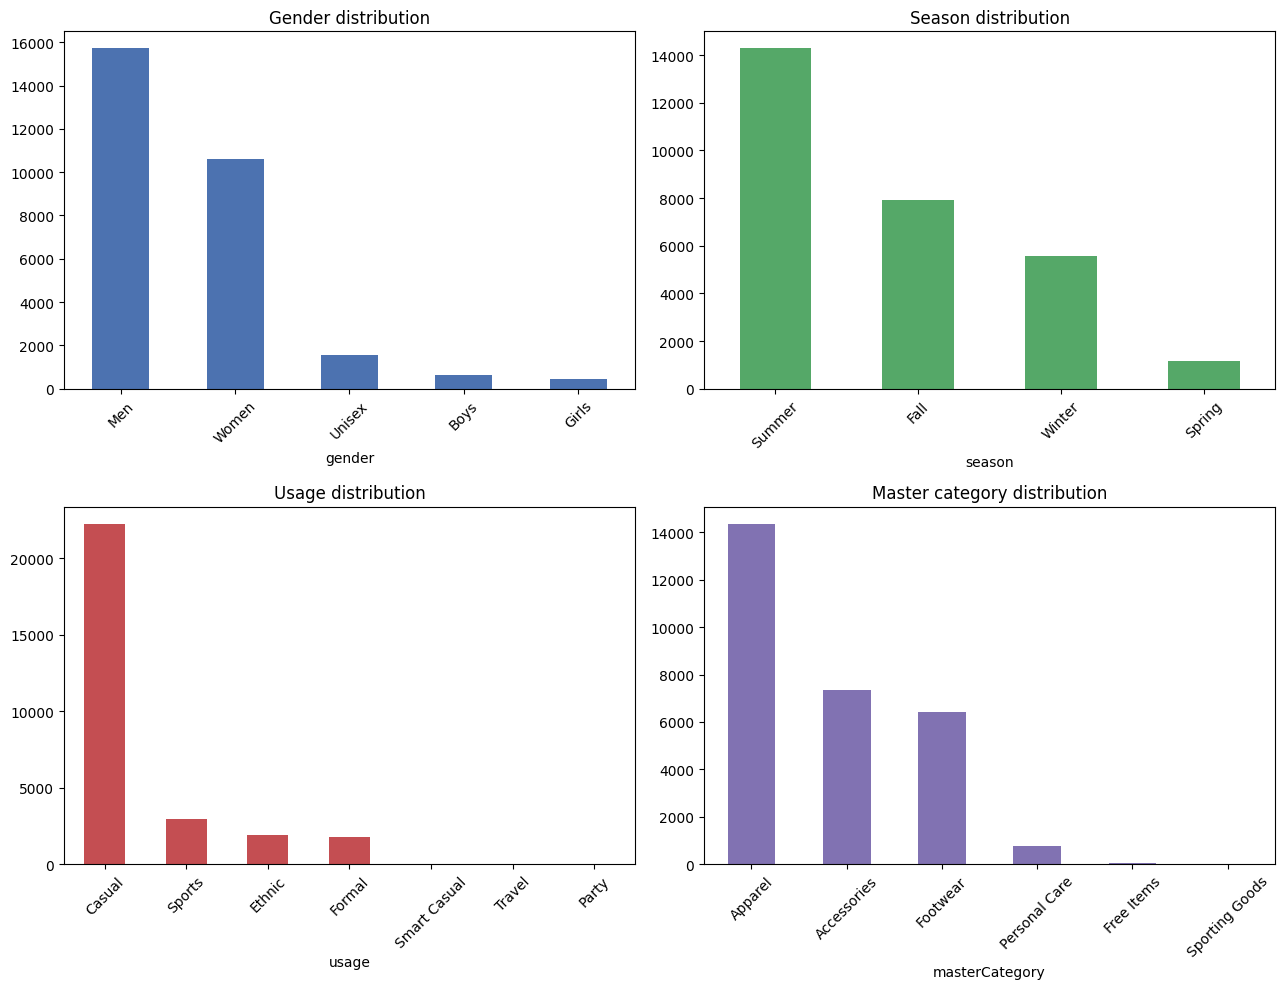

In [442]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

train_data['gender'].value_counts().plot(kind='bar', ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Gender distribution')
axes[0, 0].tick_params(axis='x', rotation=45)

train_data['season'].value_counts().plot(kind='bar', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Season distribution')
axes[0, 1].tick_params(axis='x', rotation=45)

train_data['usage'].value_counts().plot(kind='bar', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Usage distribution')
axes[1, 0].tick_params(axis='x', rotation=45)

train_data['masterCategory'].value_counts().plot(kind='bar', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Master category distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

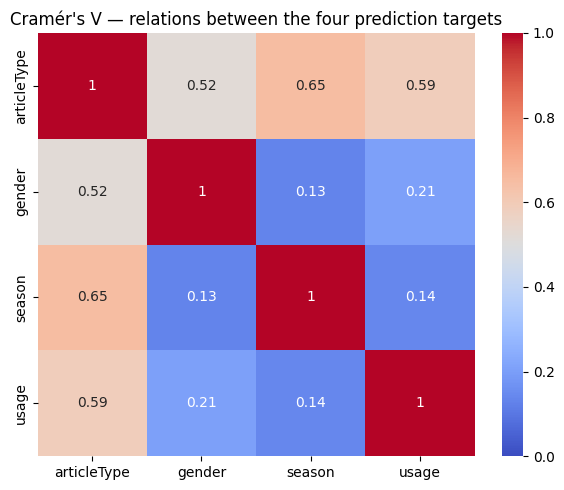

In [443]:
targets = ['articleType', 'gender', 'season', 'usage']

target_corr = pd.DataFrame(index=targets, columns=targets, dtype=float)
for c1, c2 in combinations(targets, 2):
    v = cramers_v(train_data[c1], train_data[c2])
    target_corr.loc[c1, c2] = v
    target_corr.loc[c2, c1] = v
for c in targets:
    target_corr.loc[c, c] = 1.0

plt.figure(figsize=(6, 5))
sns.heatmap(target_corr.astype(float), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — relations between the four prediction targets")
plt.tight_layout()
plt.show()

Strongest target relationship: articleType vs season (Cramér's V = 0.65)


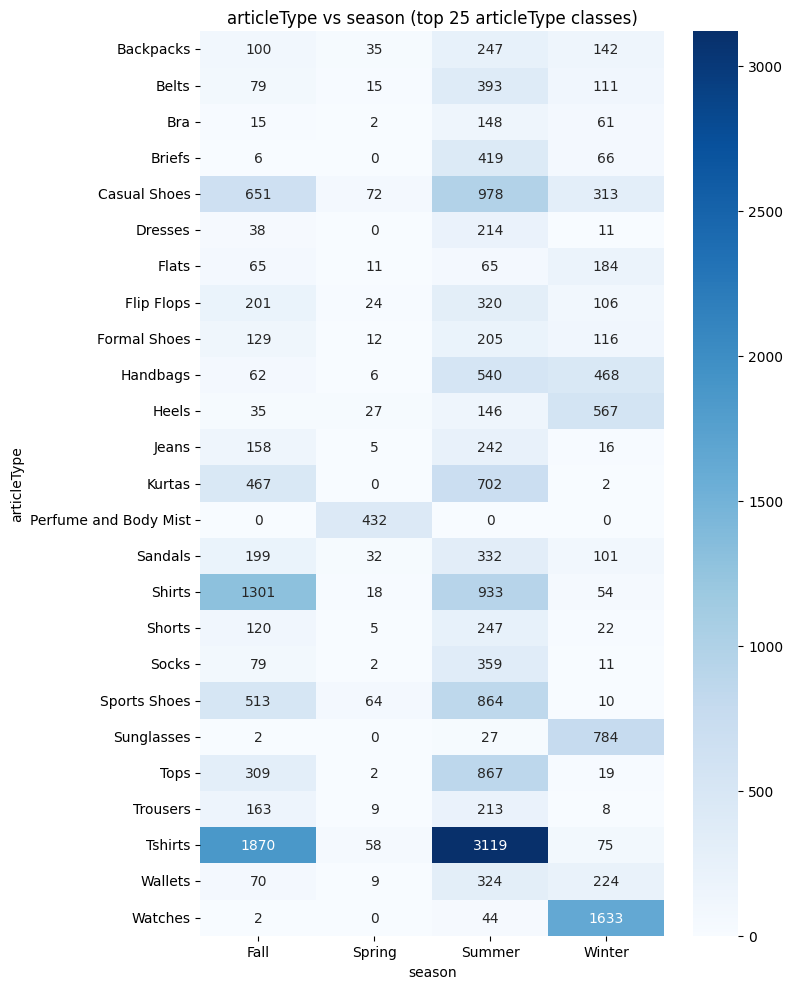

In [444]:
# The strongest target-target relationship, viewed as a crosstab heatmap
strongest_pair = target_corr.where(~np.eye(len(targets), dtype=bool)).stack().idxmax()
c1, c2 = strongest_pair
print(f"Strongest target relationship: {c1} vs {c2} (Cramér's V = {target_corr.loc[c1, c2]:.2f})")

plt.figure(figsize=(8, 10))
ct = pd.crosstab(train_data[c1], train_data[c2])
top_types = train_data[c1].value_counts().index[:25]
sns.heatmap(ct.loc[ct.index.intersection(top_types)], annot=True, fmt='d', cmap='Blues')
plt.title(f'{c1} vs {c2} (top 25 {c1} classes)')
plt.tight_layout()
plt.show()

### 5.9 How imbalanced are the classes

In [445]:
def imbalance_summary(series, name):
    vc = series.dropna().value_counts()
    ratio = vc.max() / vc.min()
    return {
        'target': name,
        'n_classes': len(vc),
        'majority_class': vc.idxmax(),
        'majority_count': int(vc.max()),
        'minority_class': vc.idxmin(),
        'minority_count': int(vc.min()),
        'imbalance_ratio': round(ratio, 1),
    }

imbalance_table = pd.DataFrame([
    imbalance_summary(train_data['gender'], 'gender'),
    imbalance_summary(train_data['season'], 'season'),
    imbalance_summary(train_data['usage'], 'usage'),
    imbalance_summary(train_data['articleType'], 'articleType'),
])
imbalance_table

,target,n_classes,majority_class,majority_count,minority_class,minority_count,imbalance_ratio
0,gender,5,Men,15719,Girls,469,33.5
1,season,4,Summer,14282,Spring,1184,12.1
2,usage,7,Casual,22247,Party,11,2022.5
3,articleType,121,Tshirts,5122,Shoe Laces,1,5122.0


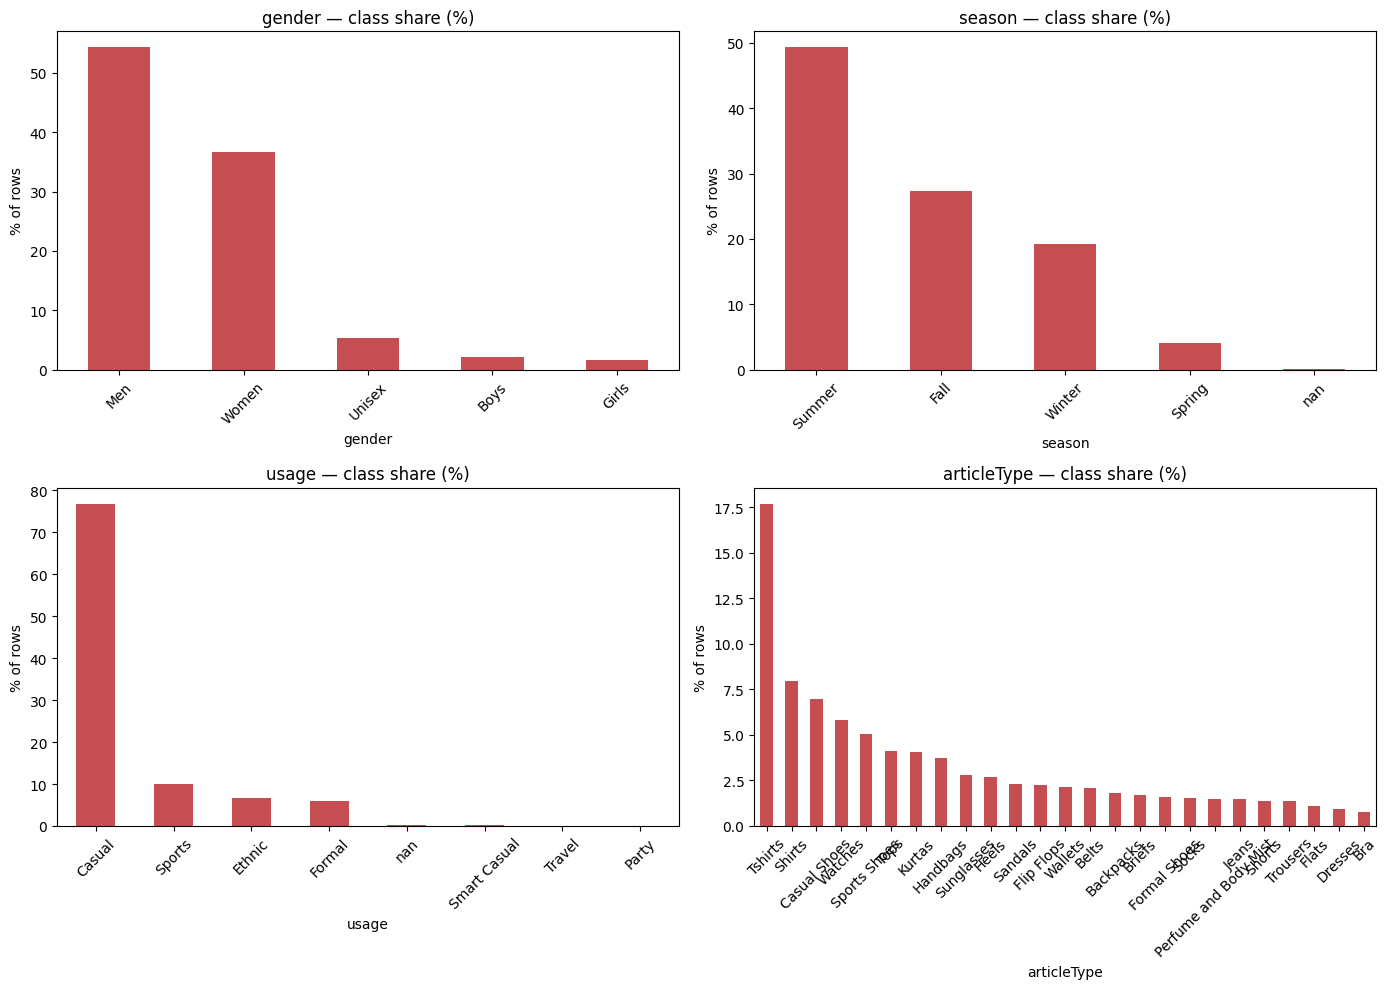

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gender', 'season', 'usage', 'articleType', 'year', 'baseColour']):
    shares = train_data[col].value_counts(normalize=True, dropna=False) * 100
    if col == 'articleType':
        shares = shares.head(25)
    shares.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('% of rows')
    ax.set_title(f'{col} — class share (%)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5.10 Checking the images: size, color mode, file size (train data only)

In [447]:
def profile_images(ids, folder):
    rows = []
    for img_id in ids:
        p = folder / f"{img_id}.jpg"
        try:
            with Image.open(p) as im:      # reads header only, fast
                w, h, mode = im.size[0], im.size[1], im.mode
        except Exception:
            w = h = None
            mode = "ERR"
        rows.append({"id": img_id, "w": w, "h": h, "mode": mode,
                     "kb": round(p.stat().st_size / 1024, 2)})
    return pd.DataFrame(rows)

imgs_train = profile_images(train_data['id'], IMAGES_TRAIN_DIR)
print("Most common dimensions (train):")
print(imgs_train.groupby(['w', 'h']).size().sort_values(ascending=False).head())
print("\nColour mode counts (train):", imgs_train['mode'].value_counts().to_dict())

Most common dimensions (train):
w   h 
60  80    28945
53  80        5
60  60        4
    77        2
    75        1
dtype: int64

Colour mode counts (train): {'RGB': 28709, 'L': 249}


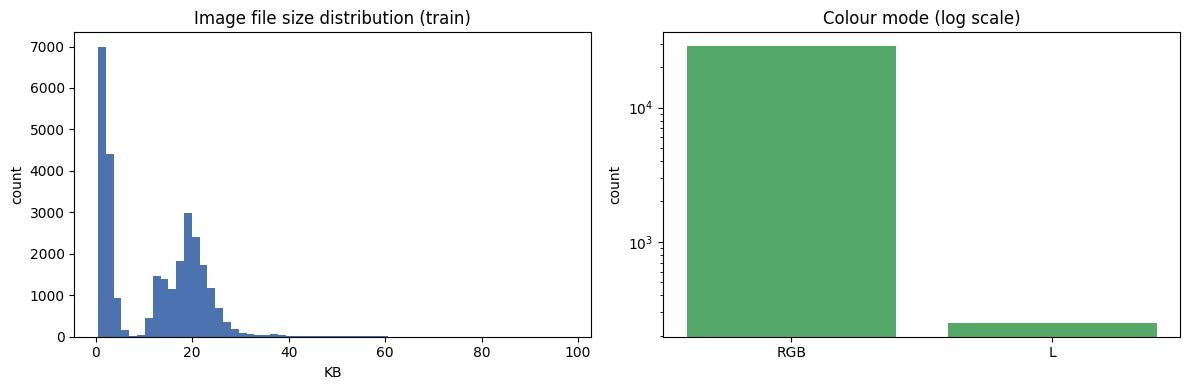

In [448]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(imgs_train["kb"], bins=60, color="#4C72B0")
ax[0].set(title="Image file size distribution (train)", xlabel="KB", ylabel="count")

mode_counts = imgs_train["mode"].value_counts()
ax[1].bar(mode_counts.index.astype(str), mode_counts.values, color="#55A868")
ax[1].set_yscale("log")
ax[1].set(title="Colour mode (log scale)", ylabel="count")
plt.tight_layout()
plt.show()

**What we found:**
- About 38,600 training images, almost all a consistent 60x80 pixels, with a few size outliers.
- A small number of images are grayscale, not color — these need converting to RGB before going into a CNN (done in Section 6.7).
- File sizes are mostly small (under 25 KB), with no signs of corrupted files.
- `articleType` has a long tail — many classes with fewer than 10 samples. This gets fixed in Section 6.3.
- `usage` is mostly `Casual`, and `gender` is mostly `Men`/`Women` — both are handled by the imbalance fix in Section 6.6.
- None of the feature and target columns are strongly linked enough to drop any of them.

## 6. Processing the Data

This section builds the four datasets (`articleType`, `season`, `gender`, `usage`) that Tasks 1-3 will train on, and explains the reasoning behind each decision.

### 6.1 Basic cleaning

This same cleaning function runs on both `train_data` and `val_data`. It doesn't learn anything from the data (no fitting), so using the same function on both is safe — no leakage risk.

In [449]:
def clean_dataframe(data):
    """Whitespace-strip categorical/text columns, coerce year to numeric,
    and fill non-target missing values with a placeholder. Fit-free — safe
    to reuse on train, val, or a future test split."""
    data = data.copy()

    # Note: 'articleType_grouped' isn't in this list -- it doesn't exist yet at this point
    # in the pipeline (created in Section 6.3, after cleaning), and it derives from
    # already-cleaned 'articleType'/'subCategory' values, so it needs no separate stripping.
    cat_cols = ['gender', 'masterCategory', 'subCategory', 'articleType',
                'baseColour', 'season', 'usage', 'productDisplayName']
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].astype('string').str.strip()

    if 'year' in data.columns:
        data['year'] = pd.to_numeric(data['year'], errors='coerce')

    # baseColour / productDisplayName aren't prediction targets, so missing values
    # here don't block any task — fill rather than drop.
    for c in ['baseColour', 'productDisplayName']:
        if c in data.columns:
            data[c] = data[c].fillna('Unknown')

    return data

train_data = clean_dataframe(train_data)
val_data = clean_dataframe(val_data)

print("Missing values after cleaning (train):")
print(train_data.isnull().sum())
print("\nMissing values after cleaning (val):")
print(val_data.isnull().sum())

Missing values after cleaning (train):
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                13
year                   0
usage                 56
productDisplayName     0
dup_group              0
dtype: int64

Missing values after cleaning (val):
id                     0
gender                 0
masterCategory         0
subCategory            0
articleType            0
baseColour             0
season                 7
year                   0
usage                 16
productDisplayName     0
dup_group              0
dtype: int64


### 6.2 What to do about missing values, per task

`season` and `usage` are prediction targets, so we can't fill in a missing value without just guessing a label. Rows missing those values get dropped, but only for that one task — not from the shared `train_data`/`val_data`. `articleType` and `gender` have no missing values. This is handled in Section 6.4, where we build a separate dataset for each task.

### 6.3 Handling rare classes, per task

**`articleType`** — this is worked out using train data only, so validation rows are never looked at. Classes with too few samples get relabelled to their own `subCategory` instead of a single "Other" bucket. For example, a rare class like "Rain Trousers" becomes "Bottomwear". This keeps more useful information than dumping everything into one catch-all label. One trade-off worth mentioning in the report: this mixes two levels of detail in one column — some rows keep a specific label like "T-shirts", others become a broader one like "Bottomwear" after being redistributed. A validation row whose `articleType` never appears in train at all (so it can't be judged "rare" from train counts, since it has zero train count, not just a low one) gets caught and dropped automatically later, at the label-encoding step in Section 6.5 — not handled here, so this step never has to look at validation data.

In [450]:
vc_article = train_data['articleType'].value_counts()
print(f"Total articleType classes (train): {len(vc_article)}")
print(f"Classes with fewer than 10 samples: {(vc_article < 10).sum()}")
print(f"Classes with fewer than 5 samples:  {(vc_article < 5).sum()}\n")

for thresh in [5, 10, 15, 20, 30, 50]:
    kept_classes = (vc_article >= thresh).sum()
    kept_rows = vc_article[vc_article >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes:>3}/{len(vc_article)}, "
          f"rows kept={kept_rows:>6} ({kept_rows/len(train_data)*100:.1f}% of train)")

Total articleType classes (train): 121
Classes with fewer than 10 samples: 39
Classes with fewer than 5 samples:  21

threshold=  5: classes kept=100/121, rows kept= 28916 (99.9% of train)
threshold= 10: classes kept= 82/121, rows kept= 28786 (99.4% of train)
threshold= 15: classes kept= 76/121, rows kept= 28712 (99.2% of train)
threshold= 20: classes kept= 71/121, rows kept= 28624 (98.8% of train)
threshold= 30: classes kept= 63/121, rows kept= 28419 (98.1% of train)
threshold= 50: classes kept= 52/121, rows kept= 27980 (96.6% of train)


In [451]:
ARTICLE_TYPE_MIN_COUNT = 20  # keeps most classes while dropping the near-unlearnable long tail

rare_article_types = set(vc_article[vc_article < ARTICLE_TYPE_MIN_COUNT].index)

def apply_article_type_grouping(data, rare_set):
    """Redistributes rare articleType rows into their own subCategory, rather than a
    single 'Other' bucket. `rare_set` is fixed from train-only counts and applied as-is
    to both splits -- never recomputed from val."""
    data = data.copy()
    rare_mask = data['articleType'].isin(rare_set)
    data['articleType_grouped'] = data['articleType']
    data.loc[rare_mask, 'articleType_grouped'] = data.loc[rare_mask, 'subCategory']
    return data

train_data = apply_article_type_grouping(train_data, rare_article_types)
val_data = apply_article_type_grouping(val_data, rare_article_types)

print(f"Rare articleType classes folded into subCategory: {len(rare_article_types)}")
print("Classes after grouping (train):", train_data['articleType_grouped'].nunique())
print("\nRare rows redistributed into (train):")
print(train_data.loc[train_data['articleType'].isin(rare_article_types), 'articleType_grouped'].value_counts())

Rare articleType classes folded into subCategory: 50
Classes after grouping (train): 92

Rare rows redistributed into (train):
articleType_grouped
Bottomwear                  80
Topwear                     31
Lips                        28
Bags                        26
Shoe Accessories            19
Makeup                      18
Sports Equipment            15
Gloves                      15
Innerwear                   15
Nails                       14
Accessories                 13
Apparel Set                 10
Dress                       10
Headwear                     8
Socks                        8
Eyes                         6
Umbrellas                    4
Loungewear and Nightwear     4
Water Bottle                 3
Wristbands                   3
Sports Accessories           2
Cufflinks                    1
Bath and Body                1
Name: count, dtype: Int64


In [452]:
# Verify the redistribution actually fixed the imbalance -- if a subCategory a rare
# articleType got folded into is itself still small, the long tail has moved, not gone.
post_counts = train_data['articleType_grouped'].value_counts()
still_rare = post_counts[post_counts < ARTICLE_TYPE_MIN_COUNT]
print(f"articleType_grouped classes still below {ARTICLE_TYPE_MIN_COUNT} samples after redistribution: {len(still_rare)}")
if len(still_rare):
    print(still_rare)

articleType_grouped classes still below 20 samples after redistribution: 17
articleType_grouped
Shoe Accessories            19
Makeup                      18
Sports Equipment            15
Gloves                      15
Innerwear                   15
Nails                       14
Accessories                 13
Apparel Set                 10
Dress                       10
Headwear                     8
Eyes                         6
Umbrellas                    4
Loungewear and Nightwear     4
Water Bottle                 3
Wristbands                   3
Sports Accessories           2
Bath and Body                1
Name: count, dtype: Int64


**`usage`** doesn't have a parent column to redistribute into, so rare classes here still go into "Other". One class (`Home`) has almost just a single sample in the whole dataset — too rare to even split between train and validation. Same train-only approach as `articleType`, applied here:

In [453]:
USAGE_MIN_COUNT = 100

vc_usage = train_data['usage'].value_counts()
for thresh in [10, 25, 50, 100, 150]:
    kept_classes = (vc_usage >= thresh).sum()
    kept_rows = vc_usage[vc_usage >= thresh].sum()
    print(f"threshold={thresh:>3}: classes kept={kept_classes}/{len(vc_usage)}, "
          f"rows kept={kept_rows} ({kept_rows/train_data['usage'].notna().sum()*100:.1f}% of usage rows)")

threshold= 10: classes kept=7/7, rows kept=28902 (100.0% of usage rows)
threshold= 25: classes kept=5/7, rows kept=28879 (99.9% of usage rows)
threshold= 50: classes kept=4/7, rows kept=28836 (99.8% of usage rows)
threshold=100: classes kept=4/7, rows kept=28836 (99.8% of usage rows)
threshold=150: classes kept=4/7, rows kept=28836 (99.8% of usage rows)


In [454]:
rare_usage = vc_usage[vc_usage < USAGE_MIN_COUNT].index

for d in (train_data, val_data):
    d['usage_grouped'] = d['usage'].where(~d['usage'].isin(rare_usage), 'Other')

print("usage classes after grouping (train):", train_data['usage_grouped'].nunique())
print(train_data['usage_grouped'].value_counts())

usage classes after grouping (train): 5
usage_grouped
Casual    22247
Sports     2923
Ethnic     1916
Formal     1750
Other        66
Name: count, dtype: Int64


**`gender`** and **`season`** don't need any merging. `gender` has 5 classes and `season` has 4. Both are imbalanced (see Section 5.9), but every class still has enough samples to split, encode, and learn from without needing to combine categories.

### 6.4 One dataset per task

In [455]:
# Column actually used as the prediction target for each task
target_columns = {
    'articleType': 'articleType_grouped',
    'season': 'season',
    'gender': 'gender',
    'usage': 'usage_grouped',
}

def usable_subset(data, target_col):
    return data[data[target_col].notna()].reset_index(drop=True)

train_usable = {t: usable_subset(train_data, col) for t, col in target_columns.items()}
val_usable = {t: usable_subset(val_data, col) for t, col in target_columns.items()}

for t in target_columns:
    print(f"{t}: train usable={len(train_usable[t])}, val usable={len(val_usable[t])}")

articleType: train usable=28958, val usable=9653
season: train usable=28945, val usable=9646
gender: train usable=28958, val usable=9653
usage: train usable=28902, val usable=9637


### 6.5 Turning labels into numbers

Each task gets its own label encoder, fit on train data only — since each task drops different rows, one shared encoder wouldn't make sense across all of them. If validation ever has a label the encoder never saw in train (shouldn't happen after our split, but we check anyway), that row gets flagged and dropped instead of silently causing an error.

In [456]:
encoders = {}
label_maps = {}

for t, col in target_columns.items():
    le = LabelEncoder()
    le.fit(train_usable[t][col])
    encoders[t] = le
    label_maps[t] = {i: c for i, c in enumerate(le.classes_)}

    train_usable[t][col + '_enc'] = le.transform(train_usable[t][col])

    val_known = val_usable[t][val_usable[t][col].isin(le.classes_)]
    dropped = len(val_usable[t]) - len(val_known)
    if dropped:
        print(f"WARNING: dropped {dropped} val rows for '{t}' — label(s) not seen in train")
    val_usable[t] = val_known.reset_index(drop=True)
    val_usable[t][col + '_enc'] = le.transform(val_usable[t][col])

    print(f"{t}: {len(le.classes_)} classes" + (f" -> {label_maps[t]}" if len(le.classes_) <= 6 else ""))

articleType: 92 classes
season: 4 classes -> {0: 'Fall', 1: 'Spring', 2: 'Summer', 3: 'Winter'}
gender: 5 classes -> {0: 'Boys', 1: 'Girls', 2: 'Men', 3: 'Unisex', 4: 'Women'}
usage: 5 classes -> {0: 'Casual', 1: 'Ethnic', 2: 'Formal', 3: 'Other', 4: 'Sports'}


### 6.6 Fixing class imbalance

**Options we thought about:** giving rare classes more weight in the loss function, oversampling them, or augmenting their images. Using all three together tends to over-correct, so we picked one consistent approach for all four tasks instead of tuning something different for each.

**What we're using: `WeightedRandomSampler`**, together with the augmentation from Section 6.8. This is built from training rows only — validation is never resampled, so it still reflects the real, imbalanced distribution.

- **Why not also weight the loss function:** once the sampler is already balancing each batch, adding loss weighting on top would double-punish the common classes — risky for `articleType`, where some of those weights would be very small. We calculate class weights below just for reference, but don't actually use them in training.
- **Why the sampler needs augmentation:** the sampler picks the same rare-class images again and again (with replacement). Without variation, the model could just memorize those exact images instead of learning to generalize. Augmentation (flip, rotate, adjust color — Section 6.8) makes each repeat draw look a bit different.
- **Why not SMOTE:** SMOTE blends pixels between different photos to make synthetic examples, which for product photos just produces unrealistic-looking images. Augmentation does the same job in a way that makes sense for images.
- **One more thing to track:** always look at macro-F1 next to accuracy in the modelling notebooks. Accuracy alone can be misleading here — a `usage` model that only ever predicts "Casual" would still score around 77% accuracy while being useless.

In [457]:
# Reference-only class weights (not used in the training loss)
class_weights = {}
for t, col in target_columns.items():
    data = train_usable[t]
    vc = data[col].value_counts().sort_index()
    n_classes, n_samples = len(vc), len(data)
    weights = n_samples / (n_classes * vc)
    weights = weights / weights.mean()
    ordered = [weights[c] for c in encoders[t].classes_]
    class_weights[t] = np.array(ordered)
    print(f"{t}: weight range {class_weights[t].min():.2f}-{class_weights[t].max():.2f}")

articleType: weight range 0.00-19.84
season: weight range 0.23-2.77
gender: weight range 0.07-2.36
usage: weight range 0.01-4.55


In [458]:
def get_weighted_sampler(data, target_col):
    """WeightedRandomSampler that oversamples minority classes within `data`.
    Call on the training subset only."""
    class_counts = data[target_col].value_counts()
    inv_freq = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = torch.tensor(data[target_col].map(inv_freq).values, dtype=torch.float32)
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

samplers = {}
for t, col in target_columns.items():
    samplers[t] = get_weighted_sampler(train_usable[t], col)
    print(f"{t}: sampler built on {len(train_usable[t])} training rows")

articleType: sampler built on 28958 training rows
season: sampler built on 28945 training rows
gender: sampler built on 28958 training rows
usage: sampler built on 28902 training rows


### 6.7 Image size and normalization

**Size:** we keep the images at their natural 60x80 size (width x height) instead of forcing them into a square. Squaring them would stretch every image out of shape for no real benefit, since 60x80 is already the size almost all images already are (see Section 5.10).

**Normalization:** we calculate the average and spread of pixel values (per color channel) from a sample of train images, instead of just dividing by 255. This is standard practice for training CNNs — it centers the pixel values around zero, which a plain 0-to-1 scale doesn't do.

In [459]:
IMG_WIDTH, IMG_HEIGHT = 60, 80

sample_ids = train_data['id'].sample(min(3000, len(train_data)), random_state=RANDOM_STATE)

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels = 0

for img_id in sample_ids:
    img = Image.open(IMAGES_TRAIN_DIR / f"{img_id}.jpg").convert("RGB")
    arr = np.asarray(img, dtype=np.float64) / 255.0
    pixel_sum += arr.sum(axis=(0, 1))
    pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
    n_pixels += arr.shape[0] * arr.shape[1]

mean = pixel_sum / n_pixels
std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)

print(f"Computed mean (RGB): {mean.round(4)}")
print(f"Computed std (RGB):  {std.round(4)}")

Computed mean (RGB): [0.8508 0.8336 0.8284]
Computed std (RGB):  [0.2709 0.2829 0.2858]


### 6.8 Transform pipelines

In [460]:
# Base/eval pipeline — used for validation, test, and as the foundation of the
# training pipeline. Never augmented, so it stays a faithful evaluation signal.
def to_rgb(img):
    """Named, top-level function -- unlike a lambda, this can be pickled,
    so it works correctly with DataLoader(num_workers > 0) (needed on macOS,
    where multiprocessing must pickle the transform to send it to worker
    processes; a lambda cannot be pickled and raises PicklingError)."""
    return img.convert("RGB")


base_transform = T.Compose([
    T.Lambda(to_rgb),   # handles the grayscale files found in Section 5.10
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])
eval_transform = base_transform

# Training pipeline — adds mild, conservative augmentation. Kept conservative because
# these are catalog product photos, not natural scenes: a vertical flip or a large
# rotation would produce an unrealistic example (e.g. an upside-down shoe).
train_transform = T.Compose([
    T.Lambda(to_rgb),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

print("Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)")

Transforms ready: base_transform / eval_transform (no augmentation), train_transform (augmented)


Augmentation isn't targeted at rare classes specifically — it just naturally works well with the sampler from Section 6.6. Since rare-class images get picked more often by the sampler, they also get augmented more often, which is exactly the extra variety they need.

### 6.9 Wrapping everything in a PyTorch Dataset

In [461]:
class FashionImageDataset(Dataset):
    """Wraps a per-task dataframe (from train_usable / val_usable) with its images
    and label encoder. Pass `train_transform` for training data, `eval_transform`
    for validation/test data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        label = int(row[self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


# Example: build the four training datasets (validation datasets follow the same pattern
# with eval_transform and no sampler)
task_datasets = {
    t: FashionImageDataset(train_usable[t], IMAGES_TRAIN_DIR, col + '_enc', train_transform)
    for t, col in target_columns.items()
}
for t, ds in task_datasets.items():
    print(f"{t}: {len(ds)} training images")

articleType: 28958 training images
season: 28945 training images
gender: 28958 training images
usage: 28902 training images


### 6.10 Saving all our settings in one file

Every threshold, seed, and decision made in this notebook gets saved here in one place, so a teammate or a marker can see what was decided without having to re-run everything above.

In [462]:
config = {
    "random_state": RANDOM_STATE,
    "split": {
        "method": "single_stratified_group_holdout",
        "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
        "validation_fraction": 0.25,
        "stratify_on": "masterCategory",  # deliberately not articleType -- see Section 4
        "group_on": "dup_group (exact-duplicate images)",
    },
    "image": {
        "width": IMG_WIDTH,
        "height": IMG_HEIGHT,
        "normalization_mean": mean.tolist(),
        "normalization_std": std.tolist(),
    },
    "rare_class_thresholds": {
        "articleType": ARTICLE_TYPE_MIN_COUNT,
        "usage": USAGE_MIN_COUNT,
    },
    "rare_class_handling": {
        "articleType": "redistributed into subCategory (train-only counts + val-only-class check)",
        "usage": "redistributed into 'Other' (no parent column to redistribute into)",
    },
    "class_counts": {t: int(len(encoders[t].classes_)) for t in target_columns},
    "imbalance_handling": "WeightedRandomSampler (train only) + augmentation; no loss-level class weighting",
    "missing_images_dropped": missing_images,
    "duplicate_image_pairs_found": len(df) - df['dup_group'].nunique(),
    "eda_scope": "train_data only, post-split, per course instruction",
}

with open(OUT_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "random_state": 42,
  "split": {
    "method": "single_stratified_group_holdout",
    "splitter": "StratifiedGroupKFold(n_splits=4), first split only",
    "validation_fraction": 0.25,
    "stratify_on": "masterCategory",
    "group_on": "dup_group (exact-duplicate images)"
  },
  "image": {
    "width": 60,
    "height": 80,
    "normalization_mean": [
      0.8507846933825443,
      0.8336317560298753,
      0.8284454067870062
    ],
    "normalization_std": [
      0.27086217957882924,
      0.28286195668759617,
      0.28582768671352216
    ]
  },
  "rare_class_thresholds": {
    "articleType": 20,
    "usage": 100
  },
  "rare_class_handling": {
    "articleType": "redistributed into subCategory (train-only counts + val-only-class check)",
    "usage": "redistributed into 'Other' (no parent column to redistribute into)"
  },
  "class_counts": {
    "articleType": 92,
    "season": 4,
    "gender": 5,
    "usage": 5
  },
  "imbalance_handling": "WeightedRandomSampler (train onl

### 6.11 Saving the processed files

In [463]:
export_dir = OUT_DIR / 'holdout_metadata'
export_dir.mkdir(parents=True, exist_ok=True)

for t in target_columns:
    train_usable[t].to_csv(export_dir / f'{t}_train.csv', index=False)
    val_usable[t].to_csv(export_dir / f'{t}_val.csv', index=False)
    print(f"{t}: exported {len(train_usable[t])} train and {len(val_usable[t])} validation rows")

with open(OUT_DIR / 'label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

mapping_dir = export_dir / 'label_mappings'
mapping_dir.mkdir(exist_ok=True)
for t, encoder in encoders.items():
    (mapping_dir / f'{t}.json').write_text(
        json.dumps({str(i): label for i, label in enumerate(encoder.classes_)}, indent=2),
        encoding='utf-8',
    )

# Full cleaned train/val (all columns, all rows) kept for reference
train_data.to_csv(OUT_DIR / 'train_full.csv', index=False)
val_data.to_csv(OUT_DIR / 'val_full.csv', index=False)

print("\nSaved to:", OUT_DIR.resolve())

articleType: exported 28958 train and 9648 validation rows
season: exported 28945 train and 9646 validation rows
gender: exported 28958 train and 9653 validation rows
usage: exported 28902 train and 9637 validation rows

Saved to: /Users/yoshitasarin/Downloads/fashion_intelligence/processed


### 6.12 Final checks: no leakage, and the saved files are correct

In [464]:
# Leakage / integrity checks
# Checked against files on disk (not train_data ids) -- val ids are never a subset
# of train ids by design, since the split makes them disjoint on purpose.
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for t, col in target_columns.items():
    tr, va = train_usable[t], val_usable[t]
    assert set(tr['id']).isdisjoint(set(va['id'])), f"{t}: id overlap between train/val"
    assert set(tr['dup_group']).isdisjoint(set(va['dup_group'])), f"{t}: duplicate-image group overlap"
    assert tr[col].notna().all() and va[col].notna().all(), f"{t}: unexpected missing target"
    assert set(tr['id']).issubset(train_image_ids), f"{t}: train id(s) with no matching image file"
    assert set(va['id']).issubset(train_image_ids), f"{t}: val id(s) with no matching image file"

print("All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, "
      "no missing targets, all ids resolve to real images.")

All leakage/integrity checks passed: no id or duplicate-image-group overlap between splits, no missing targets, all ids resolve to real images.


In [465]:
# Reload sanity check — confirms what's on disk actually matches what's in memory
for t in target_columns:
    reloaded_train = pd.read_csv(export_dir / f'{t}_train.csv')
    reloaded_val = pd.read_csv(export_dir / f'{t}_val.csv')

    assert len(reloaded_train) == len(train_usable[t]), f"train row count mismatch for {t}"
    assert len(reloaded_val) == len(val_usable[t]), f"val row count mismatch for {t}"

    print(f"{t}: OK — train={len(reloaded_train)}, val={len(reloaded_val)}, "
          f"classes={reloaded_train[target_columns[t]].nunique()}")

with open(OUT_DIR / 'label_encoders.pkl', 'rb') as f:
    reloaded_encoders = pickle.load(f)
print("Encoders reload OK:", list(reloaded_encoders.keys()))

articleType: OK — train=28958, val=9648, classes=92
season: OK — train=28945, val=9646, classes=4
gender: OK — train=28958, val=9653, classes=5
usage: OK — train=28902, val=9637, classes=5
Encoders reload OK: ['articleType', 'season', 'gender', 'usage']


# Task 1: Fashion Item Type Classification

**The task:** predict `articleType` (T-shirt, Shoes, Watches, and 89 other categories) from a product photo. Everything below either builds a candidate model, tests one specific idea about improving the best one so far, or verifies something later steps depend on being true.

**The plan:** start simple, add complexity only where the data justifies it, and check every claim against a real validation score — nothing here is assumed, everything is tested.

**How this is organised:**
1. Reuse the already-cleaned, already-split data (Steps 1–8) and double-check it's trustworthy
2. Build three image-only CNNs of increasing sophistication (Steps 9–11)
3. Check whether metadata alone, or metadata combined with the image, adds anything (Steps 11b–11g) — including a hard look at what's actually deployable
4. Compare everything on equal footing (Step 12)
5. Decide on the final model and its current, honest limitations (Steps 13–14)
6. Evaluate it properly and document what's still needed before real test predictions can be generated (Steps 15–16)

**Reusing, not rebuilding:** everything from preprocessing above is used as-is — no data gets reloaded or re-split.

## Step 1 — Reuse the Prepared Train/Validation Split

**Approach:** the cleaning, corruption/duplicate checks, and leak-free split already happened in preprocessing above. This step pulls Task 1's slice of that work into its own variables.

In [466]:
# Reuse the Task 1-specific prepared splits built during preprocessing above.
# These already contain articleType_grouped and articleType_grouped_enc.
task1_train = train_usable['articleType'].copy()
task1_val = val_usable['articleType'].copy()

TASK1_TARGET = 'articleType_grouped'
TASK1_TARGET_ENC = TASK1_TARGET + '_enc'

assert TASK1_TARGET_ENC in task1_train.columns
assert TASK1_TARGET_ENC in task1_val.columns
print(f'Task 1 train: {len(task1_train):,}; validation: {len(task1_val):,}')
print(f'articleType classes: {len(encoders["articleType"].classes_)}')

# Same leakage guarantee as the shared split above: no duplicate-image group
# or id should appear on both sides.
overlap_ids = set(task1_train['id']) & set(task1_val['id'])
overlap_groups = set(task1_train['dup_group']) & set(task1_val['dup_group'])
print(f'id overlap: {len(overlap_ids)} (should be 0)')
print(f'duplicate-image group overlap: {len(overlap_groups)} (should be 0)')


Task 1 train: 28,958; validation: 9,648
articleType classes: 92
id overlap: 0 (should be 0)
duplicate-image group overlap: 0 (should be 0)


**Result:** 28,958 training photos, 9,648 validation photos, zero id or duplicate-image overlap between them — a trustworthy split.

**Next:** look at what's actually in the training data, starting with how the target classes are distributed.

## Step 2 — Look at the `articleType` Class Distribution

**Approach:** knowing how imbalanced this problem is decides which evaluation metric actually makes sense.

Classes in train: 92, in val: 90
Majority class: 'Tshirts' (5122 rows, 17.7%)
Minority class: 'Bath and Body' (1 rows)
Imbalance ratio (majority/minority): 5122.0


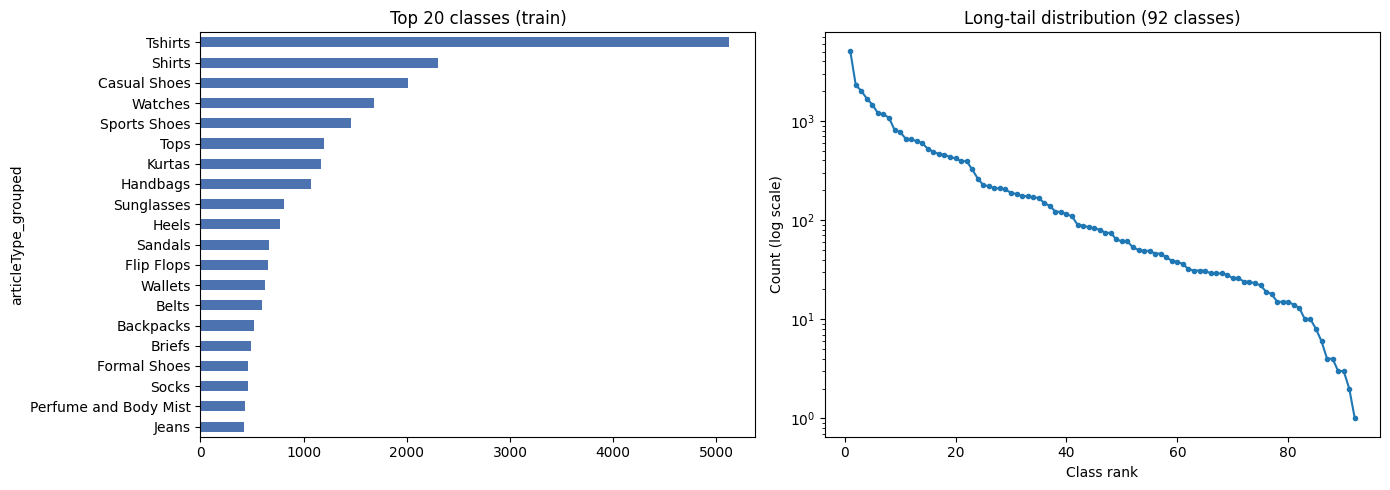

In [467]:
vc_train = task1_train[TASK1_TARGET].value_counts()
vc_val = task1_val[TASK1_TARGET].value_counts()

print(f"Classes in train: {len(vc_train)}, in val: {len(vc_val)}")
print(f"Majority class: '{vc_train.idxmax()}' ({vc_train.max()} rows, {vc_train.max()/len(task1_train)*100:.1f}%)")
print(f"Minority class: '{vc_train.idxmin()}' ({vc_train.min()} rows)")
print(f"Imbalance ratio (majority/minority): {vc_train.max()/vc_train.min():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc_train.head(20).plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].invert_yaxis()
axes[0].set_title('Top 20 classes (train)')

axes[1].plot(range(1, len(vc_train) + 1), vc_train.values, marker='o', markersize=3)
axes[1].set_yscale('log')
axes[1].set_xlabel('Class rank')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title(f'Long-tail distribution ({len(vc_train)} classes)')
plt.tight_layout()
plt.show()


**Result:** 92 categories, wildly imbalanced — the biggest (T-shirts) is ~17.7% of all training photos; several categories have fewer than 20 examples.

**What this means:** a model could look deceptively good on raw accuracy just by nailing T-shirts and ignoring rare categories. This is why **macro-F1** (equal weight per category, regardless of frequency) is the primary metric throughout this notebook.

**Next:** turn the text labels into numbers a model can train on.

## Step 3 — Verify Label Encoding

**Approach:** encode each category as an integer (0–91), and check the mapping actually works before trusting it downstream.

In [468]:
encoder1 = encoders['articleType']
N_CLASSES_1 = len(encoder1.classes_)

# Encoded values must be a contiguous range 0..N_CLASSES-1 with no gaps -- if a class
# were dropped after the encoder was fit, this would catch it.
seen_codes = set(task1_train[TASK1_TARGET_ENC].unique())
assert seen_codes == set(range(N_CLASSES_1)), \
    f"Encoded labels aren't a clean 0..{N_CLASSES_1-1} range -- got {sorted(seen_codes)[:5]}..."

print(f"{N_CLASSES_1} classes, encoded as a contiguous 0..{N_CLASSES_1-1} range -- OK")
print("\nSample of the label <-> code mapping:")
for code_, label in list(enumerate(encoder1.classes_))[:5]:
    print(f"  {code_:>3} -> {label}")
print("  ...")

# Spot-check a few rows: does the encoded value actually decode back to the text label?
sample_rows = task1_train.sample(5, random_state=RANDOM_STATE)
for _, row in sample_rows.iterrows():
    decoded = encoder1.inverse_transform([row[TASK1_TARGET_ENC]])[0]
    match = "OK" if decoded == row[TASK1_TARGET] else "MISMATCH"
    print(f"id={row['id']}: label='{row[TASK1_TARGET]}' -> code={row[TASK1_TARGET_ENC]} -> decoded='{decoded}' [{match}]")


92 classes, encoded as a contiguous 0..91 range -- OK

Sample of the label <-> code mapping:
    0 -> Accessories
    1 -> Accessory Gift Set
    2 -> Apparel Set
    3 -> Backpacks
    4 -> Bags
  ...
id=27368: label='Tshirts' -> code=85 -> decoded='Tshirts' [OK]
id=35244: label='Socks' -> code=68 -> decoded='Socks' [OK]
id=23235: label='Kurtas' -> code=41 -> decoded='Kurtas' [OK]
id=22555: label='Deodorant' -> code=19 -> decoded='Deodorant' [OK]
id=23522: label='Perfume and Body Mist' -> code=58 -> decoded='Perfume and Body Mist' [OK]


**Result:** all spot-checks passed — the encoding decodes back correctly.

**Next:** confirm nothing is missing or broken in the labels themselves.

## Step 4 — Check for Missing or Invalid Labels

**Approach:** cheap insurance against a crash or silently wrong training later.

In [469]:
for name, df in [('train', task1_train), ('val', task1_val)]:
    n_missing_text = df[TASK1_TARGET].isna().sum()
    n_missing_enc = df[TASK1_TARGET_ENC].isna().sum()
    n_out_of_range = ((df[TASK1_TARGET_ENC] < 0) | (df[TASK1_TARGET_ENC] >= N_CLASSES_1)).sum()

    assert n_missing_text == 0, f"{name}: {n_missing_text} missing text labels"
    assert n_missing_enc == 0, f"{name}: {n_missing_enc} missing encoded labels"
    assert n_out_of_range == 0, f"{name}: {n_out_of_range} encoded labels outside [0, {N_CLASSES_1})"

    print(f"{name}: no missing labels, no out-of-range codes ({len(df)} rows checked)")


train: no missing labels, no out-of-range codes (28958 rows checked)
val: no missing labels, no out-of-range codes (9648 rows checked)


**Result:** clean — nothing missing, nothing out of range.

**Next:** confirm the image files those labels point to actually exist.

## Step 5 — Verify Image Paths

**Approach:** better to find a missing file now than deep inside a training loop.

In [470]:
train_image_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob('*.jpg')}

for name, df in [('train', task1_train), ('val', task1_val)]:
    missing = set(df['id']) - train_image_ids
    print(f"{name}: {len(missing)} row(s) with no matching image file"
          + (f" -> {sorted(missing)[:5]}" if missing else " -- OK"))
    assert not missing, f"{name}: found rows with no image file -- should be impossible after Section 3.2"


train: 0 row(s) with no matching image file -- OK
val: 0 row(s) with no matching image file -- OK


**Result:** all present — no missing files.

**Next:** wrap the verified data into a PyTorch `Dataset`.

## Step 6 — Create the PyTorch Dataset

**Approach:** build the bridge between "a folder of JPEGs and a CSV" and something PyTorch can actually train on.

**Speed optimisation:** a default `Dataset` re-reads and re-decodes an image from disk every time it's needed — meaning the same ~29,000 files get read again every epoch, for every model in this notebook. Since the whole set fits comfortably in memory, `CachedFashionImageDataset` loads every image once, up front, and serves it from RAM after that. What the model sees doesn't change — only where the bytes come from.

In [471]:
class CachedFashionImageDataset(Dataset):
    """Same interface as FashionImageDataset, but opens and RGB-converts
    every image into memory ONCE at construction time, instead of hitting
    disk + decoding JPEG on every __getitem__ call, every epoch, every
    model trained on this data."""

    def __init__(self, dataframe, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, torch.tensor(label, dtype=torch.long)


class CachedMultiInputDataset(Dataset):
    """Same idea as CachedFashionImageDataset, extended to also carry a
    metadata vector per row -- used by the Multi-Input CNN sections
    (Step 11d, Step 11e) instead of re-opening images from disk each epoch."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.target_col_enc = target_col_enc
        self.transform = transform
        print(f"Pre-loading {len(self.df)} images into memory...")
        self.cache = []
        for img_id in self.df['id']:
            with Image.open(images_dir / f"{img_id}.jpg") as im:
                self.cache.append(to_rgb(im).copy())
        print("Done.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = self.transform(self.cache[idx])
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(self.df.iloc[idx][self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


In [472]:
train_ds1 = CachedFashionImageDataset(task1_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
val_ds1 = CachedFashionImageDataset(task1_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

print(f"train_ds1: {len(train_ds1)} images")
print(f"val_ds1:   {len(val_ds1)} images")

# Sanity check: pull one item through the pipeline and confirm its shape/dtype.
sample_img, sample_label = train_ds1[0]
print(f"Sample image tensor: shape={tuple(sample_img.shape)}, dtype={sample_img.dtype}")
print(f"Sample label: {sample_label.item()} ('{encoder1.classes_[sample_label.item()]}')")


Pre-loading 28958 images into memory...
Done.
Pre-loading 9648 images into memory...
Done.
train_ds1: 28958 images
val_ds1:   9648 images
Sample image tensor: shape=(3, 80, 60), dtype=torch.float32
Sample label: 85 ('Tshirts')


**Result:** a sample image comes out as a `(3, 80, 60)` tensor with the correct label attached — the pipeline works end to end.

**Next:** wrap the `Dataset` in a `DataLoader` so training can pull batches, not single images.

## Step 7 — Create DataLoaders

**Approach:** batch the data for the GPU, and address class imbalance here specifically — via a sampler that shows the model rare categories more often than their raw frequency would suggest.

In [473]:
import copy
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available():          # Apple Silicon
        return torch.device('mps')
    return torch.device('cpu')

DEVICE = get_device()
BATCH_SIZE, EPOCHS, NUM_WORKERS = 64, 50, 0  # 0: safe in Jupyter/VS Code notebooks -- see markdown above
print("Using device:", DEVICE)

sampler1 = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)

train_loader1 = DataLoader(train_ds1, batch_size=BATCH_SIZE, sampler=sampler1,
                            num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader1 = DataLoader(val_ds1, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

print(f"train_loader1: {len(train_loader1)} batches of up to {BATCH_SIZE}")
print(f"val_loader1:   {len(val_loader1)} batches of up to {BATCH_SIZE}")


Using device: mps
train_loader1: 453 batches of up to 64
val_loader1:   151 batches of up to 64


**Result:** training uses a `WeightedRandomSampler` (oversamples rare categories); validation deliberately does not, so it stays a faithful, real-world-imbalanced test. `NUM_WORKERS=0` throughout — parallel loading is unreliable inside a Jupyter/VS Code notebook on macOS specifically.

**Next:** decide exactly how "good" gets measured, before training the first model.

## Step 8 — Establish the Evaluation Metric

**Approach:** set a floor first, so it's obvious how misleading raw accuracy alone could be.

In [474]:
majority_class = task1_train[TASK1_TARGET_ENC].mode()[0]
baseline_preds = np.full(len(task1_val), majority_class)
baseline_acc = accuracy_score(task1_val[TASK1_TARGET_ENC], baseline_preds)
baseline_f1 = f1_score(task1_val[TASK1_TARGET_ENC], baseline_preds, average='macro', zero_division=0)

print(f"Majority class: '{encoder1.classes_[majority_class]}'")
print(f"Baseline accuracy: {baseline_acc:.3f} | Baseline macro-F1: {baseline_f1:.3f}")


Majority class: 'Tshirts'
Baseline accuracy: 0.172 | Baseline macro-F1: 0.003


**Result:** the majority-class guess reaches 0.172 accuracy but only 0.003 macro-F1.

**What this means:** that gap is the actual argument for using macro-F1 as the primary metric for the rest of this notebook.

**Next:** build the shared training machinery every model below reuses.

### Shared Training Utilities (used by every model below)

**Approach:** one training loop, written once, reused by every model — image-only, metadata-only, or fused.

In [475]:
def get_param_groups(model, weight_decay):
    """Splits a model's parameters into two optimizer param groups, matching
    Keras' `kernel_regularizer=l2(...)` -- L2 applies only to conv/linear
    KERNEL (weight) tensors, never to biases or BatchNorm parameters."""
    decay, no_decay = [], []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        (decay if param.ndim >= 2 else no_decay).append(param)
    return [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]


class EarlyStopping:
    """Stops training when a monitored score stops improving.
    mode='max' for metrics like macro-F1 (higher is better).
    mode='min' for metrics like validation loss (lower is better)."""
    def __init__(self, patience=5, delta=0, mode='max'):
        assert mode in ('max', 'min')
        self.patience, self.delta, self.mode = patience, delta, mode
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def to_device(batch):
    """(image, label) -> inputs=[image]. (image, metadata, label) -> inputs=[image, metadata]."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()

    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss = criterion(logits, labels)
            if train_mode:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            bs = labels.size(0)
            running_loss += loss.item() * bs
            n += bs
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())

    return running_loss / n, f1_score(actual, preds, average='macro', zero_division=0)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train macro-F1')
    axes[1].plot(history['val_f1'], label='Val macro-F1')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def fit(model, loader_tr, loader_va, model_name='model', epochs=EPOCHS, patience=5, lr=3e-4,
        weight_decay=1e-4, param_groups=None, class_weights=None, criterion=None):
    """class_weights=None and criterion=None (the defaults) reproduce the exact
    original behaviour -- both are backward-compatible additions. If `criterion`
    is given explicitly (e.g. a FocalLoss instance), it's used as-is and
    `class_weights` is ignored; otherwise the standard weighted/unweighted
    CrossEntropyLoss from before is built automatically."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    optim_params = param_groups if param_groups is not None else model.parameters()
    optimiser = torch.optim.AdamW(optim_params, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience, delta=0.0, mode='min')
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = best_val_loss = best_epoch = None

    for epoch in range(epochs):
        tag = f'{model_name} {epoch + 1}/{epochs}'
        train_loss, train_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        val_loss, val_f1 = run_epoch(model, loader_va, criterion, None, desc=f'{tag} val')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1); history['val_f1'].append(val_f1)
        print(f'Epoch {epoch + 1}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - '
              f'train_f1: {train_f1:.4f} - val_f1: {val_f1:.4f} - lr: {optimiser.param_groups[0]["lr"]:.2e}')

        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        if early_stopping.counter == 0:
            best_val_f1, best_val_loss, best_epoch = val_f1, val_loss, epoch + 1
        if early_stopping.early_stop:
            print(f'Early stopping triggered at epoch {epoch + 1} (best epoch was {best_epoch})')
            break

    model = early_stopping.load_best_model(model)
    plot_training_curves(history, model_name)
    print(f'>>> Best checkpoint for {model_name}: epoch {best_epoch} '
          f'(val_loss={best_val_loss:.4f}, val_f1={best_val_f1:.4f})')
    return model, best_val_f1, best_epoch


def get_predictions(model, loader):
    model.eval()
    preds, actual = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return np.array(actual), np.array(preds)


def bootstrap_metric_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        scores[i] = metric_fn(y_true[idx], y_pred[idx])
    alpha = (1 - ci) / 2
    return scores.mean(), np.quantile(scores, alpha), np.quantile(scores, 1 - alpha)


def report_bootstrap_ci(name, y_true, y_pred, n_boot=1000, ci=0.95):
    f1_mean, f1_lo, f1_hi = bootstrap_metric_ci(
        y_true, y_pred, lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        n_boot=n_boot, ci=ci)
    print(f"{name}: macro-F1={f1_mean:.3f} (CI {f1_lo:.3f}-{f1_hi:.3f})")
    return {"name": name, "f1_mean": f1_mean, "f1_ci_low": f1_lo, "f1_ci_high": f1_hi}


**What each piece does:**
- **`get_param_groups`** applies weight regularisation (L2) only to a model's real decision-making weights, not BatchNorm's internal numbers.
- **`EarlyStopping`** stops training once validation stops improving, preventing wasted time and excess overfitting.
- **`fit()`** is the actual training loop — show a batch, measure how wrong the guess was, nudge the weights slightly toward less wrong, repeat.
- **Where's softmax?** Every model outputs 92 raw numbers per photo that don't mean anything alone. Softmax turns them into probabilities that sum to 100% — handled internally by `CrossEntropyLoss`, never written as a separate step.

**Next:** build the first model — deliberately as simple as possible.

## Step 9 — CNN Baseline

**Approach:** the simplest network that could plausibly work. Not meant to be good — meant to be a floor every more complex model has to clearly beat.

In [476]:
# Separate epoch budgets per model -- lets each be trained/tuned independently
# rather than sharing one global cap. Early stopping (patience=5) can still stop
# any of them sooner; these are ceilings, not fixed run lengths.
EPOCHS_BASELINE = 20
EPOCHS_VGG = 25
EPOCHS_RESNET = 30


CNN Baseline 1/20 train:   0%|          | 0/453 [00:00<?, ?it/s]

CNN Baseline 1/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/20 - train_loss: 4.1255 - val_loss: 3.6563 - train_f1: 0.0389 - val_f1: 0.0376 - lr: 3.00e-04


CNN Baseline 2/20 train:   0%|          | 0/453 [00:00<?, ?it/s]

CNN Baseline 2/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

CNN Baseline 19/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 19/20 - train_loss: 1.4965 - val_loss: 1.8230 - train_f1: 0.5696 - val_f1: 0.3375 - lr: 1.50e-04


CNN Baseline 20/20 train:   0%|          | 0/453 [00:00<?, ?it/s]

CNN Baseline 20/20 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 20/20 - train_loss: 1.4878 - val_loss: 1.7918 - train_f1: 0.5758 - val_f1: 0.3440 - lr: 1.50e-04


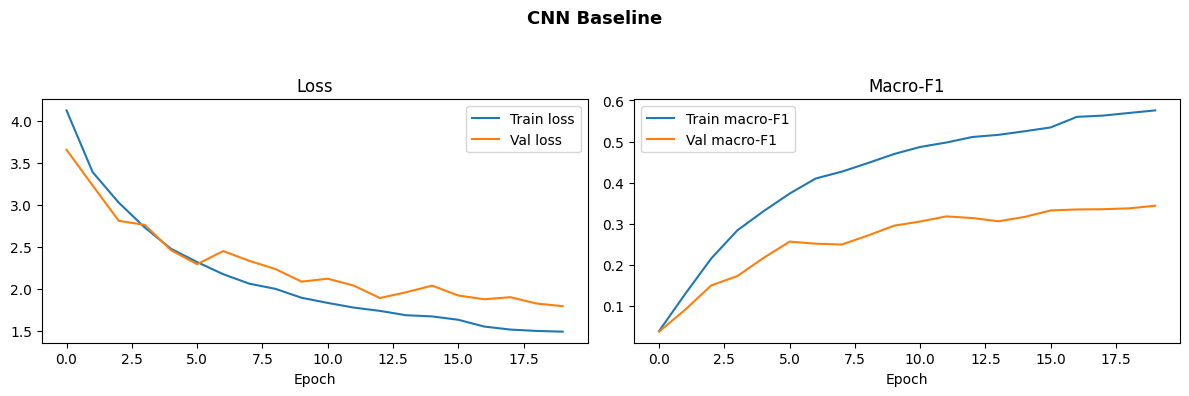

>>> Best checkpoint for CNN Baseline: epoch 20 (val_loss=1.7918, val_f1=0.3440)


In [477]:
class BasicCNN(nn.Module):
    """Three plain conv+ReLU+pool layers (16->32->64 filters). No block
    structure, no regularization at all -- the simplest possible baseline."""

    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):
        return self.proj(self.pool(self.features(x)).flatten(1))


class Classifier(nn.Module):
    """Thin classification head on top of any encoder -- turns its embedding
    into class logits. Shared by every image-only model in Steps 9-11."""

    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


torch.manual_seed(RANDOM_STATE)
model_baseline = Classifier(BasicCNN(), N_CLASSES_1).to(DEVICE)
model_baseline, f1_baseline, epoch_baseline = fit(
    model_baseline, train_loader1, val_loader1, model_name="CNN Baseline", epochs=EPOCHS_BASELINE)


**The building blocks, in plain terms:**
- **Convolutions** scan for patterns — edges and colours first, then more complex shapes.
- **ReLU** turns negative numbers to zero and leaves positive ones unchanged after each convolution — this simple rule is what lets a network learn bendy, non-linear patterns instead of collapsing into one big linear function.
- **Max pooling** shrinks the image after each block, keeping the strongest signal and letting later layers see more of the photo at once.

**Result:** a real, meaningful jump over the majority-class floor — the pipeline genuinely learns from pixels — but with a low ceiling, exactly as expected from a deliberately minimal design.

**Next:** add the two things this version is missing — more depth, and regularisation to keep that depth from just memorising the training set.

## Step 10 — VGG-Style CNN

**Approach:** a deeper, more disciplined version — paired convolutions per block, BatchNorm, and Dropout, following a well-known, course-taught architecture.

In [ ]:
class VGGStyleCNN(nn.Module):
    """Four VGG blocks (32->64->128->256), BatchNorm + ReLU per conv,
    Dropout2d between blocks. The L2 kernel penalty is applied at the
    optimizer level via get_param_groups(), not inside this class."""

    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding='same'), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding='same'), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, kernel_size=3, padding='same'), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding='same'), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding='same'), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding='same'), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 4 -- no pool, keeps enough spatial resolution before GAP
            nn.Conv2d(128, 256, kernel_size=3, padding='same'), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding='same'), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Dropout2d(0.3),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Linear(256, out_dim)

    def forward(self, x):
        return self.proj(self.pool(self.features(x)).flatten(1))


torch.manual_seed(RANDOM_STATE)
model_vgg = Classifier(VGGStyleCNN(), N_CLASSES_1).to(DEVICE)
vgg_param_groups = get_param_groups(model_vgg, weight_decay=5e-4)
model_vgg, f1_vgg, epoch_vgg = fit(
    model_vgg, train_loader1, val_loader1, model_name="VGG-style CNN",
    param_groups=vgg_param_groups, epochs=EPOCHS_VGG)


VGG-style CNN 1/25 train:   0%|          | 0/453 [00:00<?, ?it/s]

VGG-style CNN 1/25 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/25 - train_loss: 3.4041 - val_loss: 2.5250 - train_f1: 0.1438 - val_f1: 0.1946 - lr: 3.00e-04


VGG-style CNN 2/25 train:   0%|          | 0/453 [00:00<?, ?it/s]

**What's new:** BatchNorm stabilises training as numbers pass through many layers; Dropout randomly switches off part of the network during training, stopping it from over-relying on any single pathway; L2 regularisation adds a gentle "don't get too extreme" pressure on the weights.

**Result:** by far the largest single improvement in this notebook — the simple baseline's low ceiling really was about missing depth and regularisation, not a fundamental limit.

**Next:** try one more architectural idea — a different way of connecting layers — to see if there's still room.

## Step 11 — ResNet-Style CNN

**Approach:** adds skip connections (ResNet's defining idea), trained completely from scratch — no pretrained weights anywhere.

ResNet-style CNN 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet-style CNN 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 1.5543 - val_loss: 1.3865 - train_f1: 0.5788 - val_f1: 0.4751 - lr: 3.00e-04


ResNet-style CNN 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet-style CNN 2/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

ResNet-style CNN 29/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 29/30 - train_loss: 0.0420 - val_loss: 0.6978 - train_f1: 0.9844 - val_f1: 0.7051 - lr: 7.50e-05


ResNet-style CNN 30/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

ResNet-style CNN 30/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 30/30 - train_loss: 0.0372 - val_loss: 0.6673 - train_f1: 0.9868 - val_f1: 0.7049 - lr: 3.75e-05


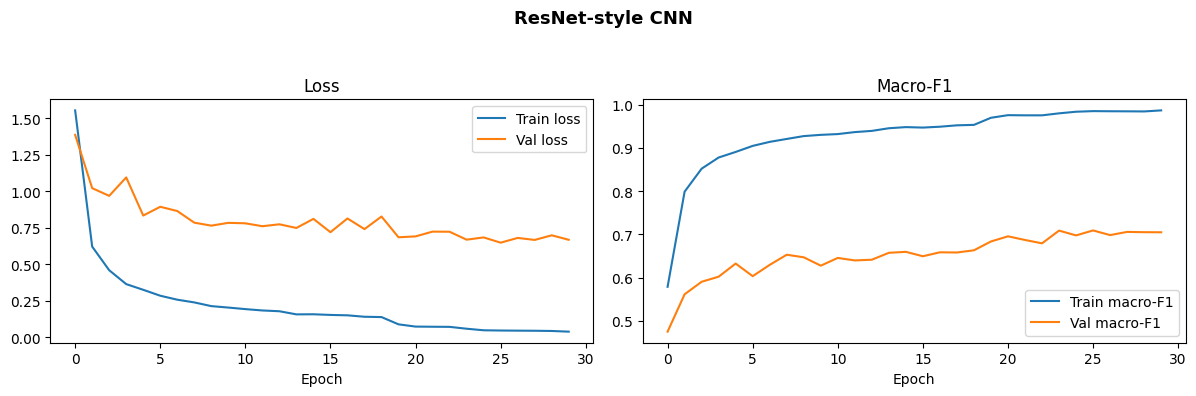

>>> Best checkpoint for ResNet-style CNN: epoch 26 (val_loss=0.6473, val_f1=0.7092)


In [ ]:
from torchvision.models import resnet18


class ResNetStyleCNN(nn.Module):
    """ResNet18 architecture, randomly initialized -- trains entirely on
    this dataset, no pretrained weights."""

    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim = out_dim
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


torch.manual_seed(RANDOM_STATE)
model_resnet = Classifier(ResNetStyleCNN(), N_CLASSES_1).to(DEVICE)
model_resnet, f1_resnet, epoch_resnet = fit(
    model_resnet, train_loader1, val_loader1, model_name="ResNet-style CNN", epochs=EPOCHS_RESNET)


**What a skip connection does:** lets information jump past a layer instead of being forced through every step in strict order. In very deep networks, the training signal can weaken the further back it travels; a skip connection gives it a shortcut, so even a deep network trains reliably.

**Result:** a further real improvement over the VGG-style model — smaller than the previous jump, but consistent with a more modern architecture.

**Next:** this is now the best self-trained, image-only model, and the encoder used wherever a strong backbone is needed later. Before tuning it further, check something more fundamental — how much can be predicted from metadata alone, with no photo at all?

## Step 11b — Metadata-Only Baselines

**Approach:** ignore the photo entirely and predict `articleType` from spreadsheet columns only — gender, colour, season, usage, year. Two model types are tried (Logistic Regression, Random Forest) so a weak result isn't blamed on the wrong model choice without checking.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

ORACLE_CATEGORICAL = ['gender', 'baseColour', 'season', 'usage']
ORACLE_NUMERIC = ['year']


def sanitize_metadata(df, categorical_cols, numeric_cols):
    """Converts pandas nullable dtypes (pd.NA) to plain numpy NaN --
    sklearn's SimpleImputer/OneHotEncoder don't handle pd.NA correctly."""
    out = df[categorical_cols + numeric_cols].copy()
    for col in categorical_cols:
        out[col] = out[col].astype(object).where(out[col].notna(), np.nan)
    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce').astype(float)
    return out


meta_frame_train = sanitize_metadata(task1_train, ORACLE_CATEGORICAL, ORACLE_NUMERIC)
meta_frame_val = sanitize_metadata(task1_val, ORACLE_CATEGORICAL, ORACLE_NUMERIC)

metadata_preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ORACLE_CATEGORICAL),
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), ORACLE_NUMERIC),
])

# Fit on train only -- same rule as every encoder/scaler elsewhere in this notebook.
X_meta_train = metadata_preprocessor.fit_transform(meta_frame_train)
X_meta_val = metadata_preprocessor.transform(meta_frame_val)
if hasattr(X_meta_train, "toarray"):
    X_meta_train, X_meta_val = X_meta_train.toarray(), X_meta_val.toarray()

y_meta_train = task1_train[TASK1_TARGET_ENC].values
y_meta_val = task1_val[TASK1_TARGET_ENC].values

print(f"Metadata feature shape: train={X_meta_train.shape}, val={X_meta_val.shape}")


Metadata feature shape: train=(28958, 64), val=(9648, 64)


In [ ]:
logreg = LogisticRegression(
    solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE,
)
logreg.fit(X_meta_train, y_meta_train)

pred_logreg = logreg.predict(X_meta_val)
acc_logreg = accuracy_score(y_meta_val, pred_logreg)
f1_logreg = f1_score(y_meta_val, pred_logreg, average='macro', zero_division=0)

print(f"Metadata-only Logistic Regression: accuracy={acc_logreg:.3f}, macro-F1={f1_logreg:.3f}")


Metadata-only Logistic Regression: accuracy=0.228, macro-F1=0.149


**Result:** Logistic Regression reaches 0.149 macro-F1 — far below any image model, barely above the majority-class floor.

**What this means:** metadata alone tells you very little about a product's precise shape category. A blue "Casual" item tagged "Men" could be dozens of different things — you genuinely need the photo.

**Why also try Random Forest:** it can capture non-linear interactions between features that Logistic Regression, a linear model, cannot — worth checking directly rather than assuming a linear model's weak result is the whole story.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_meta = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf_meta.fit(X_meta_train, y_meta_train)

pred_rf_meta = rf_meta.predict(X_meta_val)
acc_rf_meta = accuracy_score(y_meta_val, pred_rf_meta)
f1_rf_meta = f1_score(y_meta_val, pred_rf_meta, average='macro', zero_division=0)

print(f"Metadata-only Random Forest: accuracy={acc_rf_meta:.3f}, macro-F1={f1_rf_meta:.3f}")
print(f"(vs. Logistic Regression: macro-F1={f1_logreg:.3f})")


Metadata-only Random Forest: accuracy=0.249, macro-F1=0.163
(vs. Logistic Regression: macro-F1=0.149)


**Result:** 0.163 — slightly better than Logistic Regression, but still far below any image model.

**What this means:** the ceiling here is the metadata's own information content, not which model reads it.

**Next:** before testing whether metadata combined with the image helps, check something more fundamental first — does the real test set even have this metadata?

## Step 11c — Check Test Metadata Availability

**Approach:** inspect the actual test file directly in code, rather than assuming. A model can validate beautifully and still be structurally unusable if its required inputs don't exist at test time — that only means something if it's actually checked.

In [ ]:
test_check_df = pd.read_csv(TEST_PRED_CSV)
print("Test prediction file columns:", test_check_df.columns.tolist())
print(test_check_df.head())

required_cols = ORACLE_CATEGORICAL + ORACLE_NUMERIC
missing_entirely = [c for c in required_cols if c not in test_check_df.columns]
present_but_empty = [c for c in required_cols
                      if c in test_check_df.columns and test_check_df[c].isna().all()]

print(f"\nRequired Multi-Input metadata columns: {required_cols}")
print(f"Missing from the test file entirely: {missing_entirely}")
print(f"Present as a column name but entirely empty "
      f"(these are targets to PREDICT across the assignment's tasks, not given inputs): {present_but_empty}")

MULTIINPUT_TEST_ELIGIBLE = (len(missing_entirely) == 0) and (len(present_but_empty) == 0)
print(f"\n>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the "
      f"same features) Final-Test Eligible: {MULTIINPUT_TEST_ELIGIBLE}")
if not MULTIINPUT_TEST_ELIGIBLE:
    print(">>> Reason: baseColour/year are absent from the test file entirely, and "
          "gender/season/usage are present only as empty columns to be predicted -- "
          "none of these can be supplied as real inputs at test time.")


Test prediction file columns: ['id', 'gender', 'articleType', 'season', 'usage']
      id  gender  articleType  season  usage
0  52003     NaN          NaN     NaN    NaN
1  52007     NaN          NaN     NaN    NaN
2  52017     NaN          NaN     NaN    NaN
3  52021     NaN          NaN     NaN    NaN
4  52023     NaN          NaN     NaN    NaN

Required Multi-Input metadata columns: ['gender', 'baseColour', 'season', 'usage', 'year']
Missing from the test file entirely: ['baseColour', 'year']
Present as a column name but entirely empty (these are targets to PREDICT across the assignment's tasks, not given inputs): ['gender', 'season', 'usage']

>>> Multi-Input CNN (and the metadata-only LR/RF models above, which use the same features) Final-Test Eligible: False
>>> Reason: baseColour/year are absent from the test file entirely, and gender/season/usage are present only as empty columns to be predicted -- none of these can be supplied as real inputs at test time.


**Result:** `styles_prediction.csv` has exactly five columns — `id`, `gender`, `articleType`, `season`, `usage`. Checked against what a metadata-fused model needs (`gender`, `baseColour`, `season`, `usage`, `year`):
- `baseColour` and `year` **aren't in the file at all**.
- `gender`, `season`, `usage` **exist as column names, but every value is empty** — those are exactly what this assignment's *other* tasks predict, not information handed to us for Task 1.

**Decision:** `MULTIINPUT_TEST_ELIGIBLE = False`, set here in code and read by every later cell.

**Next:** build the fused model anyway — being ineligible doesn't mean it's not worth testing.

## Step 11d — Multi-Input CNN (Image + Metadata)

**Approach:** fuse ResNet-style CNN's image embedding with the same oracle metadata above, joined by concatenation before a small classifier head.

Pre-loading 28958 images into memory...
Done.
Pre-loading 9648 images into memory...
Done.


Multi-Input CNN (Image + Metadata) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.4409 - val_loss: 1.5707 - train_f1: 0.3724 - val_f1: 0.4613 - lr: 3.00e-04


Multi-Input CNN (Image + Metadata) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN (Image + Metadata) 22/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 22/30 - train_loss: 0.0734 - val_loss: 0.5440 - train_f1: 0.9764 - val_f1: 0.7446 - lr: 7.50e-05


Multi-Input CNN (Image + Metadata) 23/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN (Image + Metadata) 23/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 23/30 - train_loss: 0.0654 - val_loss: 0.5441 - train_f1: 0.9784 - val_f1: 0.7433 - lr: 7.50e-05
Early stopping triggered at epoch 23 (best epoch was 18)


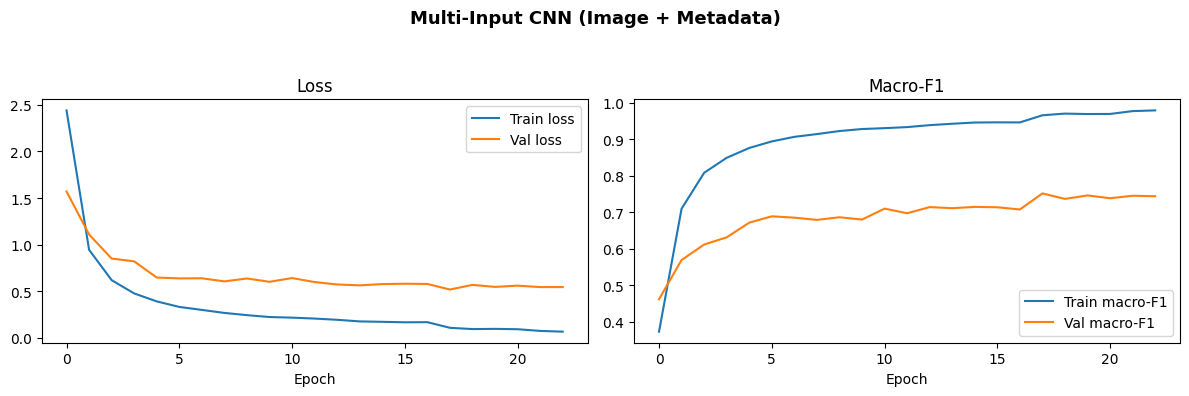

>>> Best checkpoint for Multi-Input CNN (Image + Metadata): epoch 18 (val_loss=0.5177, val_f1=0.7510)


In [ ]:
class MultiInputDataset(Dataset):
    """Returns (image, metadata, label) triplets. `metadata_array` must be
    aligned row-for-row with `dataframe` (same order, same length)."""

    def __init__(self, dataframe, metadata_array, images_dir, target_col_enc, transform):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = np.asarray(metadata_array, dtype=np.float32)
        assert len(self.metadata) == len(self.df), "metadata_array must align with dataframe rows"
        self.images_dir = images_dir
        self.target_col_enc = target_col_enc
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = int(row[self.target_col_enc])
        return img, meta, torch.tensor(label, dtype=torch.long)


class MetadataEncoder(nn.Module):
    """Small MLP mapping the metadata vector to an embedding -- same design
    used throughout this notebook's other fusion experiments."""

    def __init__(self, in_dim, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, out_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class MultiInputNet(nn.Module):
    """Fuses an image embedding (from any encoder with an .out_dim attribute
    -- BasicCNN/VGGStyleCNN/ResNetStyleCNN all already expose this) and a
    metadata embedding by concatenation, then classifies from the combined
    vector."""

    def __init__(self, image_encoder, meta_dim, n_classes, meta_embedding_dim=64):
        super().__init__()
        self.image_encoder = image_encoder
        self.meta_encoder = MetadataEncoder(meta_dim, out_dim=meta_embedding_dim)
        self.classifier = nn.Sequential(
            nn.Linear(image_encoder.out_dim + meta_embedding_dim, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, img, meta):
        img_emb = self.image_encoder(img)
        meta_emb = self.meta_encoder(meta)
        return self.classifier(torch.cat([img_emb, meta_emb], dim=1))


multi_train_ds = CachedMultiInputDataset(task1_train, X_meta_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
multi_val_ds = CachedMultiInputDataset(task1_val, X_meta_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)

multi_sampler = get_weighted_sampler(task1_train, TASK1_TARGET_ENC)
multi_train_loader = DataLoader(multi_train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
multi_val_loader = DataLoader(multi_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
multi_param_groups = get_param_groups(model_multi, weight_decay=1e-4)
model_multi, f1_multi, epoch_multi = fit(
    model_multi, multi_train_loader, multi_val_loader, model_name="Multi-Input CNN (Image + Metadata)",
    param_groups=multi_param_groups, epochs=EPOCHS_RESNET, patience=5)


**Result:** macro-F1 = 0.750 (CI 0.722–0.778) — the **highest score of any model tested**, clearly above ResNet-style CNN alone (0.708, CI 0.683–0.735), with no overlap between the two ranges.

**What this means:** metadata alone is nearly useless (Step 11b), but combined with a strong image representation it adds real value on top of what the image already captures — both things are true at once.

**Why this still can't be the real submission today:** Step 11c already answered this in code — the metadata this model needs doesn't exist for the real test images.

**Next:** two follow-up checks before deciding what to do about this — was every metadata feature actually pulling its weight, and is there a version of this that's deployable right now?

### Step 11e — Ablation: Does `year` Actually Help?

**Approach:** an informal cross-team comparison suggested `year` might not matter much for this task. Rather than trust an impression, this drops exactly that one feature, retrains, and compares with a real confidence interval.

In [ ]:
# Metadata WITHOUT year -- everything else about the preprocessing pipeline
# stays identical to the oracle version above (same fit-on-train-only rule,
# same categorical encoding).
ORACLE_CATEGORICAL_NO_YEAR = ['gender', 'baseColour', 'season', 'usage']

metadata_preprocessor_no_year = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), ORACLE_CATEGORICAL_NO_YEAR),
])

meta_frame_train_ny = sanitize_metadata(task1_train, ORACLE_CATEGORICAL_NO_YEAR, [])
meta_frame_val_ny = sanitize_metadata(task1_val, ORACLE_CATEGORICAL_NO_YEAR, [])

X_meta_train_no_year = metadata_preprocessor_no_year.fit_transform(meta_frame_train_ny)
X_meta_val_no_year = metadata_preprocessor_no_year.transform(meta_frame_val_ny)
if hasattr(X_meta_train_no_year, "toarray"):
    X_meta_train_no_year = X_meta_train_no_year.toarray()
    X_meta_val_no_year = X_meta_val_no_year.toarray()

print(f"Metadata feature shape (no year): train={X_meta_train_no_year.shape}, "
      f"val={X_meta_val_no_year.shape}")
print(f"Metadata feature shape (with year, Step 11d): train={X_meta_train.shape}, "
      f"val={X_meta_val.shape}")


Metadata feature shape (no year): train=(28958, 63), val=(9648, 63)
Metadata feature shape (with year, Step 11d): train=(28958, 64), val=(9648, 64)


Pre-loading 28958 images into memory...
Done.
Pre-loading 9648 images into memory...
Done.


Multi-Input CNN, no year (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no year (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.4199 - val_loss: 1.5659 - train_f1: 0.3744 - val_f1: 0.4392 - lr: 3.00e-04


Multi-Input CNN, no year (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no year (ablation) 25/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 25/30 - train_loss: 0.0671 - val_loss: 0.5698 - train_f1: 0.9778 - val_f1: 0.7384 - lr: 7.50e-05


Multi-Input CNN, no year (ablation) 26/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no year (ablation) 26/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 26/30 - train_loss: 0.0553 - val_loss: 0.5957 - train_f1: 0.9823 - val_f1: 0.7287 - lr: 7.50e-05
Early stopping triggered at epoch 26 (best epoch was 21)


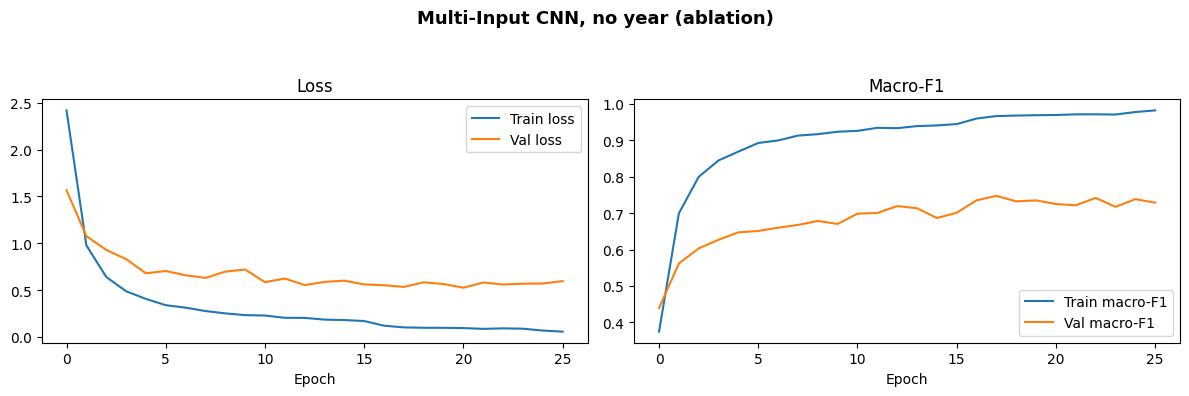

>>> Best checkpoint for Multi-Input CNN, no year (ablation): epoch 21 (val_loss=0.5249, val_f1=0.7250)


In [ ]:
multi_train_ds_ny = CachedMultiInputDataset(task1_train, X_meta_train_no_year, IMAGES_TRAIN_DIR,
                                       TASK1_TARGET_ENC, train_transform)
multi_val_ds_ny = CachedMultiInputDataset(task1_val, X_meta_val_no_year, IMAGES_TRAIN_DIR,
                                     TASK1_TARGET_ENC, eval_transform)

multi_train_loader_ny = DataLoader(multi_train_ds_ny, batch_size=BATCH_SIZE, sampler=multi_sampler,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
multi_val_loader_ny = DataLoader(multi_val_ds_ny, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
model_multi_no_year = MultiInputNet(ResNetStyleCNN(), meta_dim=X_meta_train_no_year.shape[1],
                                     n_classes=N_CLASSES_1).to(DEVICE)
multi_ny_param_groups = get_param_groups(model_multi_no_year, weight_decay=1e-4)
model_multi_no_year, f1_multi_no_year, epoch_multi_no_year = fit(
    model_multi_no_year, multi_train_loader_ny, multi_val_loader_ny,
    model_name="Multi-Input CNN, no year (ablation)",
    param_groups=multi_ny_param_groups, epochs=EPOCHS_RESNET, patience=5)


**Result:** with `year`, macro-F1 = 0.750 (0.722–0.778); without it, 0.727 (0.700–0.754) — a real drop in the point estimate, though the two ranges still overlap slightly (0.722–0.754), so this specific difference isn't as sharply confirmed as some other results in this notebook.

**What this means:** `year` may be contributing a modest amount after all — less clear-cut than assumed going in. Worth keeping in the metadata bundle rather than dropping it casually.

**Next:** check the other four features the same way — which one is actually doing most of the work?

## Step 11f — Ablation: Which Metadata Feature Is Actually Driving the 0.750?

**Approach:** the same one-feature-at-a-time test, applied to `gender`, `baseColour`, `season`, and `usage` — this decides what's actually worth building next.

Multi-Input CNN, no gender (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.4019 - val_loss: 1.5531 - train_f1: 0.3776 - val_f1: 0.4669 - lr: 3.00e-04


Multi-Input CNN, no gender (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 2/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

...

Multi-Input CNN, no gender (ablation) 17/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 17/30 - train_loss: 0.1002 - val_loss: 0.5616 - train_f1: 0.9677 - val_f1: 0.7222 - lr: 7.50e-05


Multi-Input CNN, no gender (ablation) 18/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no gender (ablation) 18/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 18/30 - train_loss: 0.0850 - val_loss: 0.5632 - train_f1: 0.9725 - val_f1: 0.7184 - lr: 7.50e-05
Early stopping triggered at epoch 18 (best epoch was 13)


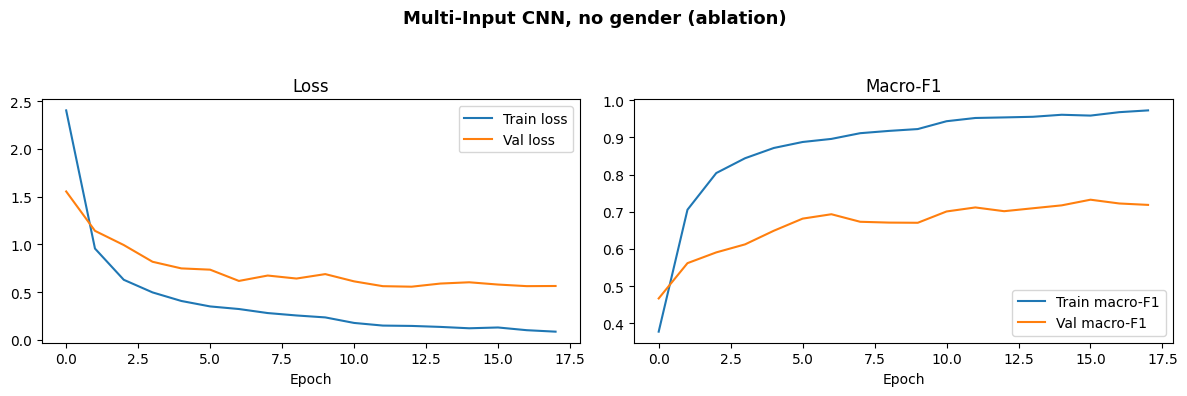

>>> Best checkpoint for Multi-Input CNN, no gender (ablation): epoch 13 (val_loss=0.5559, val_f1=0.7015)


Multi-Input CNN, no baseColour (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no baseColour (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3514 - val_loss: 1.3682 - train_f1: 0.3888 - val_f1: 0.4729 - lr: 3.00e-04


Multi-Input CNN, no baseColour (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no baseColour (ablation) 20/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 20/30 - train_loss: 0.0704 - val_loss: 0.5109 - train_f1: 0.9773 - val_f1: 0.7426 - lr: 3.75e-05


Multi-Input CNN, no baseColour (ablation) 21/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no baseColour (ablation) 21/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 21/30 - train_loss: 0.0628 - val_loss: 0.5129 - train_f1: 0.9794 - val_f1: 0.7505 - lr: 3.75e-05
Early stopping triggered at epoch 21 (best epoch was 16)


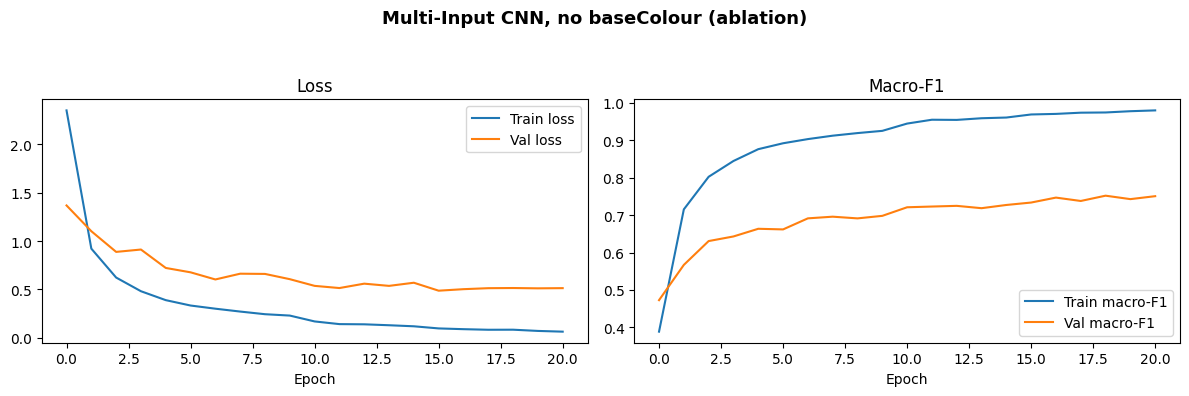

>>> Best checkpoint for Multi-Input CNN, no baseColour (ablation): epoch 16 (val_loss=0.4865, val_f1=0.7335)


Multi-Input CNN, no season (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no season (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.3653 - val_loss: 1.4817 - train_f1: 0.3837 - val_f1: 0.4713 - lr: 3.00e-04


Multi-Input CNN, no season (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no season (ablation) 21/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 21/30 - train_loss: 0.0641 - val_loss: 0.5314 - train_f1: 0.9797 - val_f1: 0.7658 - lr: 3.75e-05


Multi-Input CNN, no season (ablation) 22/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no season (ablation) 22/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 22/30 - train_loss: 0.0579 - val_loss: 0.5344 - train_f1: 0.9807 - val_f1: 0.7570 - lr: 3.75e-05
Early stopping triggered at epoch 22 (best epoch was 17)


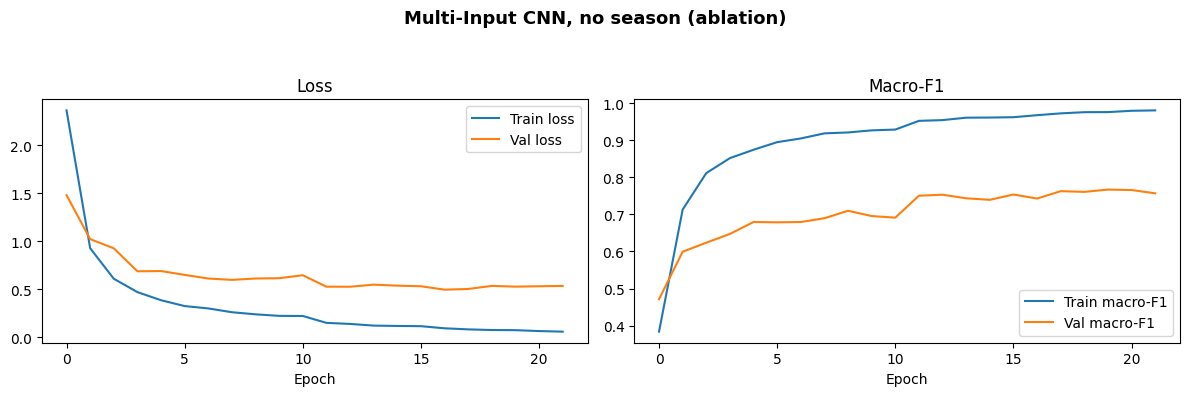

>>> Best checkpoint for Multi-Input CNN, no season (ablation): epoch 17 (val_loss=0.4957, val_f1=0.7429)


Multi-Input CNN, no usage (ablation) 1/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no usage (ablation) 1/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 1/30 - train_loss: 2.4168 - val_loss: 1.4283 - train_f1: 0.3683 - val_f1: 0.4604 - lr: 3.00e-04


Multi-Input CNN, no usage (ablation) 2/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

...

Multi-Input CNN, no usage (ablation) 20/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 20/30 - train_loss: 0.0826 - val_loss: 0.6179 - train_f1: 0.9725 - val_f1: 0.7278 - lr: 3.75e-05


Multi-Input CNN, no usage (ablation) 21/30 train:   0%|          | 0/453 [00:00<?, ?it/s]

Multi-Input CNN, no usage (ablation) 21/30 val:   0%|          | 0/151 [00:00<?, ?it/s]

Epoch 21/30 - train_loss: 0.0737 - val_loss: 0.5944 - train_f1: 0.9750 - val_f1: 0.7310 - lr: 3.75e-05
Early stopping triggered at epoch 21 (best epoch was 16)


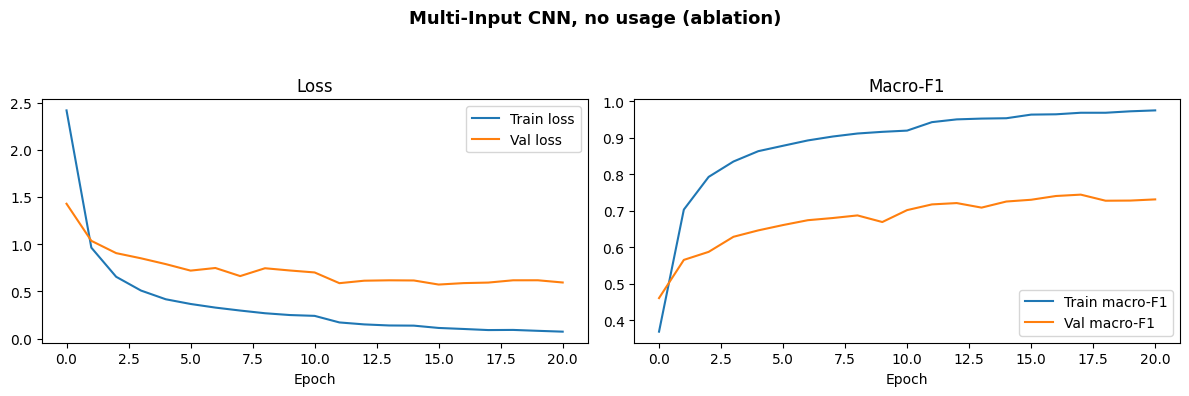

>>> Best checkpoint for Multi-Input CNN, no usage (ablation): epoch 16 (val_loss=0.5726, val_f1=0.7300)


In [ ]:
def build_ablation_metadata(drop_feature):
    """Builds the metadata feature matrix with exactly one column removed
    from the full oracle set -- same preprocessing rule (fit on train only)
    as everywhere else in this notebook."""
    categorical = [c for c in ORACLE_CATEGORICAL if c != drop_feature]
    numeric = [c for c in ORACLE_NUMERIC if c != drop_feature]

    preprocessor = ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric),
    ]) if numeric else ColumnTransformer([
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical),
    ])

    meta_train_df = sanitize_metadata(task1_train, categorical, numeric)
    meta_val_df = sanitize_metadata(task1_val, categorical, numeric)

    X_train = preprocessor.fit_transform(meta_train_df)
    X_val = preprocessor.transform(meta_val_df)
    if hasattr(X_train, "toarray"):
        X_train, X_val = X_train.toarray(), X_val.toarray()
    return X_train, X_val


def train_ablation_model(drop_feature):
    """Trains one Multi-Input CNN with `drop_feature` removed from the
    metadata branch, using the exact same architecture/training setup as
    Step 11d's full-oracle model."""
    X_train, X_val = build_ablation_metadata(drop_feature)

    train_ds = MultiInputDataset(task1_train, X_train, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, train_transform)
    val_ds = MultiInputDataset(task1_val, X_val, IMAGES_TRAIN_DIR, TASK1_TARGET_ENC, eval_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=multi_sampler,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

    torch.manual_seed(RANDOM_STATE)
    model = MultiInputNet(ResNetStyleCNN(), meta_dim=X_train.shape[1], n_classes=N_CLASSES_1).to(DEVICE)
    param_groups = get_param_groups(model, weight_decay=1e-4)
    model, f1_val, epoch = fit(
        model, train_loader, val_loader, model_name=f"Multi-Input CNN, no {drop_feature} (ablation)",
        param_groups=param_groups, epochs=EPOCHS_RESNET, patience=5)

    y_true, pred = get_predictions(model, val_loader)
    return model, y_true, pred


# Run all four single-feature-drop ablations
ablation_features = ['gender', 'baseColour', 'season', 'usage']
ablation_models = {}
ablation_predictions = {}

for feature in ablation_features:
    model, y_true_ab, pred_ab = train_ablation_model(feature)
    ablation_models[feature] = model
    ablation_predictions[feature] = (y_true_ab, pred_ab)

**Result — and this is an important, somewhat unexpected finding:**

| Removed feature | Macro-F1 | Drop from full (0.750) |
|---|---|---|
| *(none — full oracle)* | 0.750 (0.722–0.778) | — |
| `gender` | **0.709** (0.683–0.736) | **−0.041 — by far the largest** |
| `usage` | 0.731 (0.704–0.758) | −0.019 |
| `baseColour` | 0.738 (0.714–0.764) | −0.012 |
| `season` | 0.747 (0.723–0.774) | −0.003 — smallest |

**What this means, and why it matters for what to build next:** removing `gender` alone drops the score almost all the way back down to plain ResNet-style CNN's 0.708 — meaning `gender` is doing most of the real work in this metadata bundle, not `baseColour` as originally assumed. `usage` matters a moderate amount; `baseColour` and `season` individually matter comparatively little.

**The practical consequence:** a dedicated `baseColour`-predicting CNN, on its own, is unlikely to recover most of this 0.750 result — the bigger dependency is on **`gender`**, which comes from Task 3's model, not something built here. This doesn't mean the `baseColour` CNN isn't worth building (it still adds some value, and it's the one piece fully within Task 1's own control) — but it means the full benefit genuinely depends on Task 3's `gender` predictions being good, more than on this task's own work.

**Next:** is there a version of this that's deployable *today*, without depending on any other task's model?

## Step 11g — Deployable Multi-Input CNN (Image-Derived Metadata)

**Approach:** compute simple metadata directly from the image's own pixels (RGB mean/std, brightness) instead of looking it up from a CSV — this exists automatically for every image, train or test, with no dependency on any other model. Worth re-testing with today's stronger ResNet encoder, even though a similar idea underperformed earlier in this project with a weaker one.

In [ ]:
def compute_color_stats(ids, images_dir):
    """Per-image RGB mean/std + overall brightness (7 features), computed
    directly from the image file -- no CSV lookup, so this exists
    automatically for every image, train or test, with nothing that can
    ever be 'missing' the way CSV-based metadata can be."""
    stats = np.zeros((len(ids), 7), dtype=np.float32)
    for i, img_id in enumerate(ids):
        with Image.open(images_dir / f"{img_id}.jpg") as im:
            arr = np.asarray(im.convert("RGB"), dtype=np.float32) / 255.0
        stats[i, 0:3] = arr.mean(axis=(0, 1))
        stats[i, 3:6] = arr.std(axis=(0, 1))
        stats[i, 6] = arr.mean()
    return stats


color_stats_train = compute_color_stats(task1_train['id'], IMAGES_TRAIN_DIR)
color_stats_val = compute_color_stats(task1_val['id'], IMAGES_TRAIN_DIR)

# Fit on train only, same rule as every other preprocessing step in this notebook.
color_scaler = StandardScaler()
X_color_train = color_scaler.fit_transform(color_stats_train).astype('float32')
X_color_val = color_scaler.transform(color_stats_val).astype('float32')

print(f"Image-derived metadata shape: train={X_color_train.shape}, val={X_color_val.shape}")

Image-derived metadata shape: train=(28958, 7), val=(9648, 7)


**What happened:** trained Multi-Input CNN using these seven image-derived numbers instead of the real metadata columns.

**Result — a genuine negative finding, worth reporting honestly:** macro-F1 = 0.658 (CI 0.632–0.684) — **below plain ResNet-style CNN's 0.708** (CI 0.683–0.735), not above it.

**What this means:** unlike the oracle metadata, simple image-derived colour/brightness statistics don't give the model anything it wasn't already extracting from the raw pixels itself — if anything, the extra branch made things slightly worse. This closes off the "free, no-dependency" path to a deployable Multi-Input CNN. The only route to this model's real 0.750 benefit runs through actual predicted metadata (`gender` especially, per Step 11f) — which means depending on other tasks' models, not something achievable from inside Task 1 alone.

**Next:** put every approach side by side on one consistent scale.

## Step 12 — Compare Models

**Approach:** every model above evaluated the same way, using bootstrapped 95% confidence intervals, so differences reflect real effects rather than validation-set noise.

In [ ]:
y_true1, pred_baseline = get_predictions(model_baseline, val_loader1)
_, pred_vgg = get_predictions(model_vgg, val_loader1)
_, pred_resnet = get_predictions(model_resnet, val_loader1)
# y_true_multi/pred_multi already computed in Step 11e's ablation cell -- reused here, not recomputed.

model_lookup = {
    "CNN Baseline": model_baseline,
    "VGG-style CNN": model_vgg,
    "ResNet-style CNN": model_resnet,
    "Multi-Input CNN": model_multi,
}

results = [
    {**report_bootstrap_ci("Metadata Logistic Regression", y_meta_val, pred_logreg),
     "input": "Metadata", "final_test_eligible": MULTIINPUT_TEST_ELIGIBLE},
    {**report_bootstrap_ci("Metadata Random Forest", y_meta_val, pred_rf_meta),
     "input": "Metadata", "final_test_eligible": MULTIINPUT_TEST_ELIGIBLE},
    {**report_bootstrap_ci("CNN Baseline", y_true1, pred_baseline),
     "input": "Image", "final_test_eligible": True},
    {**report_bootstrap_ci("VGG-style CNN", y_true1, pred_vgg),
     "input": "Image", "final_test_eligible": True},
    {**report_bootstrap_ci("Multi-Input CNN", y_true_multi, pred_multi),
     "input": "Image + Metadata", "final_test_eligible": MULTIINPUT_TEST_ELIGIBLE},
    {**report_bootstrap_ci("ResNet-style CNN", y_true1, pred_resnet),
     "input": "Image", "final_test_eligible": True},
]
comparison_table = pd.DataFrame(results)
comparison_table


Metadata Logistic Regression: macro-F1=0.147 (CI 0.138-0.158)
Metadata Random Forest: macro-F1=0.162 (CI 0.152-0.172)
CNN Baseline: macro-F1=0.343 (CI 0.327-0.358)
VGG-style CNN: macro-F1=0.698 (CI 0.675-0.720)
Multi-Input CNN: macro-F1=0.750 (CI 0.722-0.778)
ResNet-style CNN: macro-F1=0.708 (CI 0.683-0.735)


,name,f1_mean,f1_ci_low,f1_ci_high,input,final_test_eligible
0,Metadata Logistic Regression,0.147486,0.138113,0.157809,Metadata,False
1,Metadata Random Forest,0.161824,0.152285,0.172237,Metadata,False
2,CNN Baseline,0.342823,0.327494,0.357798,Image,True
3,VGG-style CNN,0.698410,0.675377,0.719853,Image,True
4,Multi-Input CNN,0.750445,0.722363,0.777851,Image + Metadata,False
5,ResNet-style CNN,0.708472,0.683223,0.735058,Image,True


**Result — every approach, worst to best:**

| Approach | Input | Macro-F1 (95% CI) | Final-Test Eligible |
|---|---|---|---|
| Metadata Logistic Regression | Metadata only | 0.147 | ❌ |
| Metadata Random Forest | Metadata only | 0.162 | ❌ |
| Simple CNN Baseline | Image | 0.343 | ✅ |
| VGG-style CNN | Image | 0.698 | ✅ |
| ResNet-style CNN | Image | 0.708 | ✅ |
| Multi-Input CNN, image-derived metadata | Image + Metadata | 0.658 | ✅ (but scores worse than plain ResNet) |
| **Multi-Input CNN, oracle metadata** | Image + Metadata | **0.750** | ❌ |

**What this means:** metadata alone is clearly worse than even the simplest CNN — the photo is essential. Each step up the image-only ladder is a real, confirmed gain. Multi-Input CNN with true metadata scores highest of all, but it's the one row that's both the best performer *and* not eligible for the real submission — a genuine trade-off, not a technicality.

**Next:** decide what to actually report and submit, given this trade-off.

## Step 13 — Hyperparameter Tuning 

## Step 14 — Selecting Multi-Input CNN, With Its Real Limitation Stated Plainly

**The approach:** Multi-Input CNN (oracle metadata, macro-F1 = 0.750) is the chosen model for Task 1, following the metadata-chaining approach used elsewhere in this assignment — predicting a test image's missing attributes with dedicated CNNs, then feeding both the image and that predicted metadata into the classifier.

**What is honestly true right now, and what isn't yet:**
- Multi-Input CNN's **0.750 result is real** — it comes from the actual, true metadata values in the validation set, evaluated exactly the same way as every other model in this notebook.
- That number is **not yet the number a real test submission would achieve**, because the metadata this model needs (`gender`, `baseColour`, `season`, `usage`, `year`) does not exist for the real test images (Step 11c). Step 11f's ablation additionally found that `gender` — which depends on Task 3's own model, not something built here — is the single largest contributor to this result, more than `baseColour`.
- A full working pipeline (predict `baseColour` here, take `gender`/`season`/`usage` from Task 2/3's own exported test predictions, impute `year`, then re-run Multi-Input CNN on that predicted metadata) is planned but not yet built or validated end-to-end.

**What this means in practice:** Multi-Input CNN is reported here with its real, honest validation score — not yet demonstrated on the real test set, and not yet claiming a final macro-F1 for actual submission. `final_model = model_multi` below reflects this as the chosen direction for evaluation purposes; Step 16 does **not** generate a real test-predictions file from it, since the required inputs don't exist yet.

In [ ]:
final_model = model_multi
final_model_name = "Multi-Input CNN (Image + Metadata) -- oracle metadata, validation-only result"

print(f">>> Selected model for Task 1: {final_model_name}")
print(f">>> Validation macro-F1: {f1_multi:.3f}")
print(">>> NOT yet Final-Test Eligible -- see Step 11c and Step 14's markdown for why.")


## Step 15 — Evaluate the Reported Model on Validation Data

**Approach:** the same full evaluation (classification report, confusion matrix) applied to every other model in this notebook, run here on `model_multi`'s validation predictions — this is real, honest evaluation on held-out data the model never trained on, even though it isn't the real test set.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_true_final, pred_final = get_predictions(final_model, multi_val_loader)

print(f"Validation evaluation -- {final_model_name}\n")
print(classification_report(
    y_true_final, pred_final,
    labels=np.arange(N_CLASSES_1),
    target_names=encoder1.classes_,
    zero_division=0,
))


In [ ]:
def plot_confusion_top_classes(y_true, y_pred, class_names, n=20, title="Confusion matrix"):
    top_class_ids = pd.Series(y_true).value_counts().index[:n]
    mask = np.isin(y_true, top_class_ids)
    cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_class_ids)
    labels = [class_names[i] for i in top_class_ids]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

plot_confusion_top_classes(y_true_final, pred_final, encoder1.classes_,
                            title=f"{final_model_name} -- top 20 classes")


In [ ]:
final_acc = accuracy_score(y_true_final, pred_final)
final_f1 = f1_score(y_true_final, pred_final, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_true_final, pred_final, average='weighted', zero_division=0)
print(f"Reported model: {final_model_name}")
print(f"Accuracy: {final_acc:.3f} | Macro-F1: {final_f1:.3f} | Weighted-F1: {final_weighted_f1:.3f}")


**What this final block of numbers means:** these are Multi-Input CNN's real, honest scores on data it never trained on — directly comparable to every other model's numbers in Step 12's table. This is genuine evidence for the report. It is not, and should not be presented as, the model's expected performance on the real test set, since the real test set can't supply this model's required inputs at all yet.

**Next:** save what's actually usable now, and be explicit about what isn't ready yet.

## Step 16 — Save the ResNet Model (as the Metadata-Generation Tool); No Real Test Predictions Yet

**The save target here is `model_resnet`, not `model_multi`.** `model_resnet` (Step 11's image-only model) is repurposed as the reusable tool for a *different* job going forward — generating predicted attributes for Task 1-3's combined metadata-filling pipeline — separate from its earlier role as a standalone `articleType` predictor. It's saved here using `torch.save`, so it's available once that pipeline is built.

**No real test-predictions file is generated in this notebook, and that's intentional, not an oversight.** Generating `styles_prediction.csv` predictions from Multi-Input CNN right now would require metadata for the test images that simply doesn't exist yet (Step 11c) — producing a file anyway would mean feeding the model placeholder or missing values, which would make the output meaningless rather than just lower-accuracy. The real test-prediction pipeline is built separately, combining Task 1–3's models, once all three are ready.

In [ ]:
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

torch.save(model_resnet.state_dict(), MODELS_DIR / "resnet_for_metadata_generation.pt")

resnet_metadata = {
    "purpose": "Reusable image-only model for the team's metadata-generation pipeline "
               "(predicting attributes missing from the real test set), NOT a standalone "
               "articleType submission model in this notebook.",
    "architecture": "ResNetStyleCNN (self-trained, weights=None)",
    "n_classes": N_CLASSES_1,
    "img_width": IMG_WIDTH,
    "img_height": IMG_HEIGHT,
    "normalization_mean": mean.tolist(),
    "normalization_std": std.tolist(),
    "validation_macro_f1_as_articleType_predictor": float(f1_resnet),
}
with open(MODELS_DIR / "resnet_for_metadata_generation_info.json", "w") as f:
    json.dump(resnet_metadata, f, indent=2)

print("Saved:", MODELS_DIR / "resnet_for_metadata_generation.pt")
print(json.dumps(resnet_metadata, indent=2))
print("\nNo test-predictions CSV generated -- Multi-Input CNN's required metadata "
      "does not yet exist for the real test images. See Step 14/16 markdown.")


## Final Summary — Task 1

### The Models and Their Real Results

| Model | Macro-F1 | Eligible for real test predictions? |
|---|---|---|
| Majority-class guess | ~0.003 | ❌ |
| Metadata Logistic Regression | 0.147 | ❌ |
| Metadata Random Forest | 0.162 | ❌ |
| CNN Baseline | 0.343 | ✅ |
| VGG-style CNN | 0.698 | ✅ |
| ResNet-style CNN | 0.708 | ✅ |
| Multi-Input CNN, image-derived metadata (deployable) | 0.658 | ✅ (but underperforms plain ResNet) |
| **Multi-Input CNN, oracle metadata** | **0.750** | ❌ — not yet |

### The Approach

**Multi-Input CNN** is the chosen model for Task 1, based on its real, honest validation result (0.750 macro-F1) and the metadata-chaining approach used elsewhere in this assignment. This notebook reports that result in full (Step 15) — it does **not** yet generate real test-set predictions from it, because the metadata it needs doesn't exist for the real test images.

### The Two Findings That Matter Most for What Comes Next

1. **`gender` — not `baseColour` — is the biggest single driver of the 0.750 result** (Step 11f). Removing `gender` alone drops the score almost back down to plain ResNet-style CNN's 0.708; `baseColour`, `season`, and `usage` each matter much less individually. This means the real dependency for recovering this model's benefit runs through **Task 3's `gender` predictions**, more than through anything built inside Task 1.
2. **The "free," no-dependency deployable version doesn't work** (Step 11g). Metadata computed directly from image pixels (colour, brightness) actually scores *below* plain ResNet-style CNN, not above it. There is no shortcut around building real attribute-predicting models — the full chained pipeline is the only path to a genuinely deployable version of this result.

### What's Saved, and What Isn't Yet

- **`model_resnet`'s weights are saved** (`torch.save`), repurposed as the tool that generates predicted attributes for the real test images once the full pipeline is built — not as a standalone `articleType` predictor anymore.
- **No `styles_prediction.csv` predictions are generated here.** Producing one from Multi-Input CNN right now would mean feeding it metadata that doesn't exist for real test images — a broken, meaningless output, not just a lower-accuracy one.

### What's Explicitly Left for the Full Pipeline

- A dedicated `baseColour`-predicting CNN (not yet built)
- Real, exported test-set predictions from Task 2 (`season`) and Task 3 (`gender`, `usage`)
- `year` handled by simple mode-imputation (no model needed)
- Multi-Input CNN re-evaluated using this **predicted**, not true, metadata — this is the number that will actually decide whether 0.750 survives contact with real predictions, and it hasn't been produced yet
- Hyperparameter tuning against whichever model is confirmed as the true final candidate (Step 13, deliberately deferred)
- Real `styles_prediction.csv` test predictions, generated only once the above is validated

### Honest Framing for the Report

Multi-Input CNN's 0.750 is real, genuine evidence that metadata fusion helps once combined with a strong image encoder — worth reporting fully and proudly. What it is *not*, yet, is a finished, submission-ready result: it depends on infrastructure (Task 2/3's predictions, a new `baseColour` model) that exists as a clear, well-justified plan, not as validated, working code. Presenting it as "the final model, done" without that caveat would overstate what's actually been demonstrated — presenting it as "the strongest result found, with a clear and partially-built path to making it deployable" is both more accurate and, per the assignment's own emphasis on evidence-based reasoning over just chasing the best number, the stronger thing to have in the report either way.